
# Machine Learning Model for Loan Approval

### BLUF (Bottom Line Up Front)

FinTech Innovations can use machine learning to support its loan approval process by identifying patterns in historical loan applications and providing consistent predictions. In this analysis, five classification algorithms were evaluated and the strongest tuned model achieved 96.58% accuracy and a 99.45% ROC-AUC on the test set, with an estimated business cost of $3.91 million based on the specified costs of false negatives and false positives. The results demonstrate strong predictive performance, while also highlighting the importance of business cost, interpretability, fairness, and ongoing monitoring when using machine learning to support lending decisions.

## Business Understanding

### 1.1 Business Problem

FinTech Innovations currently relies heavily on manual review by loan officers when making loan approval decisions. This process can be time-consuming and may result in inconsistent decisions between applicants.

The company wants to improve this process by using historical loan application data to develop a machine learning solution that can support loan approval decisions. The dataset contains information about applicants, their financial characteristics, loan details, and historical loan approval outcomes.

The main business objective is to develop a data-driven classification model that can help identify applications that are likely to be approved while considering the financial consequences of incorrect decisions.

A successful solution should improve the consistency and efficiency of the screening process while providing results that can be interpreted and evaluated by business and risk stakeholders.



### 1.2 Key Stakeholders and Their Needs

| Stakeholder                    | Needs                                                                 |
| ------------------------------ | --------------------------------------------------------------------- |
| Loan applicants                | Faster, consistent and transparent loan decisions                     |
| Loan officers                  | A reliable tool that supports the manual review process               |
| Risk Analytics team            | A model with strong predictive performance and appropriate validation |
| FinTech Innovations management | Improved efficiency while controlling financial losses                |
| Risk and compliance teams      | An interpretable and well-documented decision-support process         |

The needs of these stakeholders should be considered when selecting the model, evaluation metrics, and implementation approach.


### 1.3 Model Error Implications

The business has provided two different costs for incorrect loan decisions:

* **Cost of denying a creditworthy applicant:** $8,000 average lost profit per missed good loan.
* **Cost of approving a bad loan that defaults:** $50,000 average loss.

These costs mean that the two types of classification errors do not have the same business impact.

A **false negative** occurs when an application that should be approved is predicted as not approved. In the business context, this represents a potentially creditworthy applicant being denied and results in an estimated $8,000 opportunity cost.

A **false positive** occurs when an application predicted as approved ultimately represents a bad lending decision. According to the business scenario, this can result in an estimated $50,000 loss.

Because the cost of these errors is asymmetric, accuracy alone will not be sufficient to evaluate the model. Precision, recall, ROC-AUC and a custom business-cost metric will also be considered.


### 1.4 Choice of Modeling Approach

A **classification approach** will be used for this project.

The dataset contains a historical `LoanApproved` outcome that represents whether an application was approved or not. This is a categorical outcome with two possible classes, making binary classification appropriate.

A classification model also fits the requirements of the project because its predictions can be evaluated using a confusion matrix, precision, recall, ROC-AUC and other classification metrics.

A regression approach could be used if the primary objective were to predict a continuous risk score. However, the available historical approval outcome provides a direct classification target, so classification is selected for this analysis.


### 1.5 Modeling Goals and Success Criteria

The main modeling goal is to develop a classification model that can distinguish between historical loan approval outcomes using applicant and loan characteristics.

The model should:

* Provide useful predictive performance on previously unseen applications.
* Correctly identify approved and non-approved applications.
* Reduce costly classification errors.
* Provide results that can be interpreted by business and risk stakeholders.
* Be evaluated using metrics that reflect both statistical performance and business impact.

#### Evaluation Metrics

The following metrics will be used:

**1. Accuracy**

Accuracy measures the proportion of all predictions that are correct.

It will be reported as a general performance measure, but it will not be used as the only evaluation metric because the target classes may be imbalanced.

**2. Precision**

Precision measures the proportion of applications predicted as approved that were actually approved in the historical data.

Precision is useful because it indicates how reliable the model's approval predictions are.

**3. Recall**

Recall measures the proportion of historically approved applications that the model correctly identifies.

Recall is important because a low recall means that the model may miss many applications that were historically approved.

**4. ROC-AUC**

ROC-AUC measures the model's ability to distinguish between the two classes across different classification thresholds.

It provides a threshold-independent measure of discrimination and will be useful when comparing candidate models.

#### Custom Business-Cost Metric

Because the financial consequences of the two error types are different, a custom business-cost metric will also be considered.

The business provides:

* False negative cost = $8,000
* False positive cost = $50,000

Therefore:

**Total Business Cost = (False Negatives × $8,000) + (False Positives × $50,000)**

This metric allows model performance to be considered from the perspective of the financial consequences of classification errors rather than predictive accuracy alone.


### 1.6 Baseline Performance Targets

A simple majority-class classifier will be used as the baseline model. This baseline predicts the most common class for every application.

The baseline provides a reference point against which the machine learning models can be compared.

The project will aim for the following improvements over the baseline:

* ROC-AUC should demonstrate meaningful discrimination above random classification.
* Precision and recall should provide useful identification of both classes.
* The final model should demonstrate improved predictive performance compared with the majority-class baseline.
* The business-cost metric should be examined to understand the financial consequences of the model's errors.

The exact baseline values will be calculated after loading and examining the dataset. This prevents assumptions about the target-class distribution from being made before the data is analyzed.

Model selection will consider the combination of predictive performance, business cost, interpretability, and practical implementation considerations rather than relying on a single metric.


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [1]:
# Imports

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns when inspecting the dataset
pd.set_option("display.max_columns", None)

# Set visualization style
sns.set_style("whitegrid")

c:\Users\Maggie\anaconda3\envs\learn-env\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\Users\Maggie\anaconda3\envs\learn-env\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
c:\Users\Maggie\anaconda3\envs\learn-env\lib\site-packages\numpy\.libs\libopenblas.PYQHXLVVQ7VESDPUVUADXEVJOBGHJPAY.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [3]:
# Load the dataset

df = pd.read_csv("financial_loan_data.csv")

# Display the first 5 rows
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [4]:
# Check the number of rows and columns

df.shape

(20000, 35)

In [5]:
# Display the column names

df.columns

Index(['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus',
       'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration',
       'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus',
       'MonthlyDebtPayments', 'CreditCardUtilizationRate',
       'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
       'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved',
       'RiskScore'],
      dtype='object')

In [6]:
# Examine the structure and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [7]:
# Generate descriptive statistics for numerical variables

df.describe()

,Age,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,19428.000000,20000.000000,2.000000e+04,2.000000e+04,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,0.993000,0.285735,0.100050,23.993650,14.957300,4949.148446,1782.555100,9.696440e+04,3.625241e+04,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,0.986965,0.160211,0.300074,4.945436,8.371552,6628.404969,2245.378812,1.207999e+05,4.725151e+04,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,0.000000,0.001720,0.000000,8.000000,1.000000,73.000000,24.000000,2.098000e+03,3.720000e+02,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,0.000000,0.161035,0.000000,21.000000,8.000000,1542.000000,551.000000,3.118025e+04,1.119675e+04,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,1.000000,0.264454,0.000000,24.000000,15.000000,2988.500000,1116.000000,6.069900e+04,2.220300e+04,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,2.000000,0.390327,0.000000,27.000000,22.000000,5869.250000,2126.000000,1.174052e+05,4.314650e+04,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,7.000000,0.902253,1.000000,45.000000,29.000000,200089.000000,52572.000000,2.619627e+06,1.417302e+06,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [8]:
# Identify categorical variables

categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['AnnualIncome', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus',
       'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose'],
      dtype='object')

In [9]:
# Display the unique values in each categorical variable

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


AnnualIncome:
['$39,948.00' '$39,709.00' '$40,724.00' ... '$30,180.00' '$41,025.00'
 '$53,227.00']

EmploymentStatus:
['Employed' 'Self-Employed' 'Unemployed']

EducationLevel:
['Master' 'Associate' 'Bachelor' 'High School' nan 'Doctorate']

MaritalStatus:
['Married' 'Single' nan 'Divorced' 'Widowed']

HomeOwnershipStatus:
['Own' 'Mortgage' 'Rent' 'Other']

BankruptcyHistory:
['No' 'Yes']

LoanPurpose:
['Home' 'Debt Consolidation' 'Education' 'Other' 'Auto']


### Missing Value Analysis

The dataset was examined for missing values to identify potential data-quality
issues that may affect model development. Missing values are particularly
important in this loan-approval problem because applicant information may not
always be complete.

The analysis will identify which variables contain missing observations and
the proportion of the dataset affected. These findings will guide the
preprocessing strategy used later in the modeling pipeline.

In [10]:
# Check for missing values

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

EducationLevel            901
MaritalStatus            1331
SavingsAccountBalance     572
dtype: int64

In [11]:
# Calculate the percentage of missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]

EducationLevel           4.505
MaritalStatus            6.655
SavingsAccountBalance    2.860
dtype: float64

In [12]:
# Create a summary of missing values

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary[missing_summary["Missing Count"] > 0]

missing_summary.sort_values("Missing Percentage", ascending=False)

,Missing Count,Missing Percentage
MaritalStatus,1331,6.655
EducationLevel,901,4.505
SavingsAccountBalance,572,2.860


### Interpretation of Missing Values

The dataset contains missing values in three variables: `MaritalStatus`, `EducationLevel`, and `SavingsAccountBalance`.

`MaritalStatus` has the highest amount of missing data, with 1,331 missing observations (6.655% of the dataset). `EducationLevel` has 901 missing observations (4.505%), while `SavingsAccountBalance` has 572 missing observations (2.860%).

Although the proportion of missing values is relatively small for each variable, these missing observations need to be handled during preprocessing because machine learning models generally require complete input data. The appropriate treatment will depend on the feature type and will be incorporated into the preprocessing pipeline rather than handled manually at this stage.

The missing-value pattern also represents a potential data-quality consideration because incomplete applicant information could affect loan-approval predictions.

### Target Variable Distribution

The target variable for this classification problem is `LoanApproved`. Examining its distribution is important for understanding the proportion of approved and non-approved applications and determining whether the dataset contains class imbalance.

Class imbalance is particularly important in this business problem because false approvals and false denials have different financial consequences.

In [13]:
# Examine the distribution of the target variable

target_counts = df["LoanApproved"].value_counts().sort_index()

target_percentages = (
    df["LoanApproved"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

target_summary

,Count,Percentage
LoanApproved,,
0,15220,76.1
1,4780,23.9


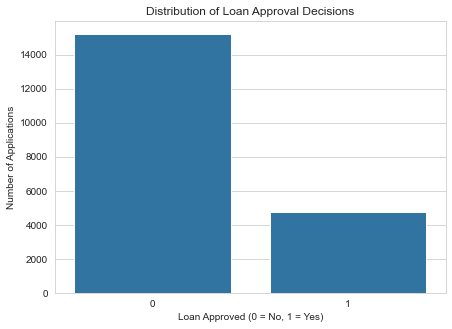

In [14]:
# Visualize the target distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="LoanApproved")

plt.title("Distribution of Loan Approval Decisions")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Number of Applications")

plt.show()

### Interpretation of Target Distribution

The target variable `LoanApproved` is imbalanced. Of the 20,000 loan applications, 15,220 applications (76.1%) were not approved, while 4,780 applications (23.9%) were approved.

This class imbalance is important for model development because accuracy alone may give a misleading impression of model performance. A model could achieve relatively high accuracy by primarily predicting the majority class while performing poorly on approved applications.

Therefore, model evaluation will consider multiple metrics, including precision, recall, ROC-AUC, and the business cost of false positive and false negative decisions. The financial consequences of these errors will be considered when selecting and evaluating the final model.

### Numerical Feature Distributions

The numerical variables were examined to understand their distributions, central tendencies, spread, and potential outliers. This is important because unusual distributions or extreme values may affect model performance and may also reveal important characteristics of the loan applicants.

The analysis will focus on variables related to applicant characteristics, financial position, credit behavior, and loan characteristics.

In [15]:
# Identify numerical variables

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

numerical_columns

Index(['Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration',
       'NumberOfDependents', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults',
       'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio', 'LoanApproved', 'RiskScore'],
      dtype='object')

In [20]:
# Remove the target variable from the numerical predictors

numerical_features = [
    column for column in numerical_columns
    if column != "LoanApproved"
]

numerical_features

['Age',
 'CreditScore',
 'Experience',
 'LoanAmount',
 'LoanDuration',
 'NumberOfDependents',
 'MonthlyDebtPayments',
 'CreditCardUtilizationRate',
 'NumberOfOpenCreditLines',
 'NumberOfCreditInquiries',
 'DebtToIncomeRatio',
 'PreviousLoanDefaults',
 'PaymentHistory',
 'LengthOfCreditHistory',
 'SavingsAccountBalance',
 'CheckingAccountBalance',
 'TotalAssets',
 'TotalLiabilities',
 'MonthlyIncome',
 'UtilityBillsPaymentHistory',
 'JobTenure',
 'NetWorth',
 'BaseInterestRate',
 'InterestRate',
 'MonthlyLoanPayment',
 'TotalDebtToIncomeRatio',
 'RiskScore']

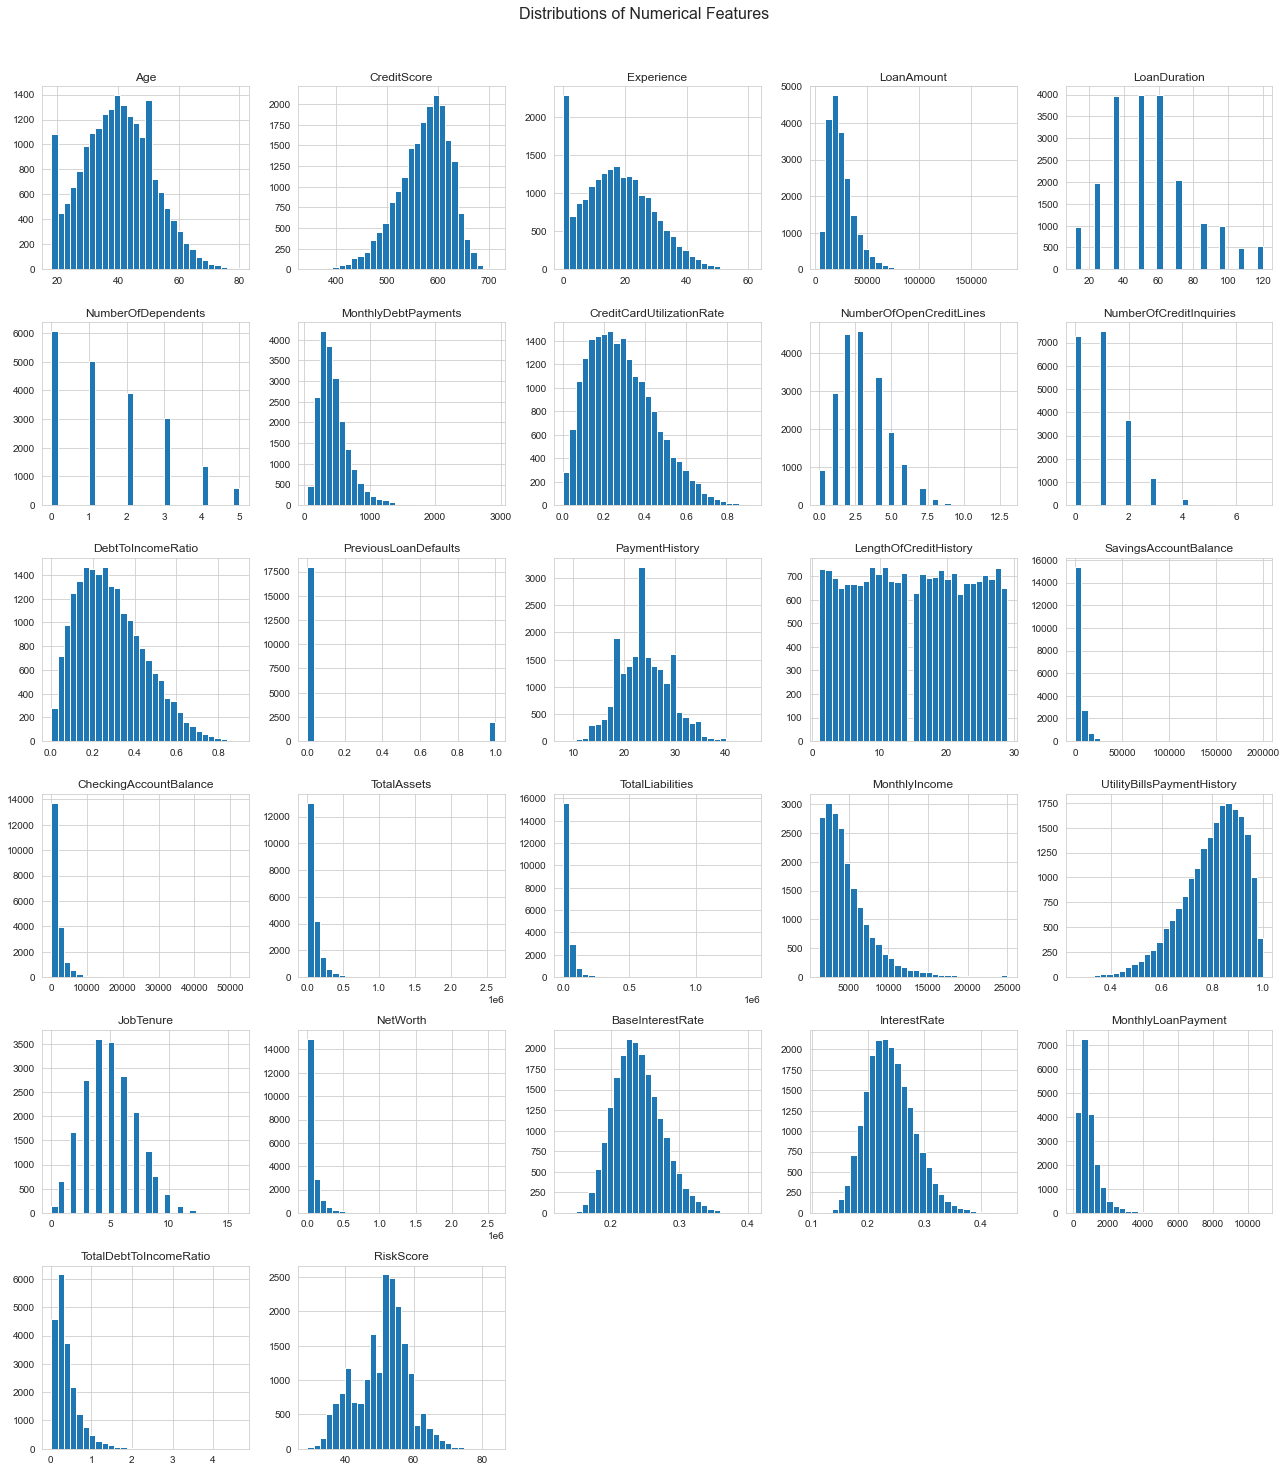

In [21]:
# Plot distributions of numerical features

df[numerical_features].hist(
    figsize=(18, 20),
    bins=30
)

plt.suptitle(
    "Distributions of Numerical Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### Observations from Numerical Feature Distributions

The numerical feature distributions show substantial variation across applicant characteristics, financial measures, credit behavior, and loan characteristics.

Several financial variables, including `LoanAmount`, `MonthlyDebtPayments`, `SavingsAccountBalance`, `CheckingAccountBalance`, `TotalAssets`, `TotalLiabilities`, `NetWorth`, and `MonthlyLoanPayment`, are strongly right-skewed. This indicates that most applicants have relatively smaller values, while a smaller number of applicants have substantially larger values.

Credit-related variables such as `CreditScore`, `CreditCardUtilizationRate`, `DebtToIncomeRatio`, and `TotalDebtToIncomeRatio` also show noticeable variation and skewness. These distributions may contain potential outliers that should be investigated before modeling.

The distributions of `BaseInterestRate` and `InterestRate` appear more approximately symmetric, while variables such as `NumberOfDependents`, `NumberOfOpenCreditLines`, and `NumberOfCreditInquiries` are discrete and concentrated around a limited number of values.

These patterns are important for preprocessing and modeling. In particular, skewed numerical variables and potential outliers should be considered when selecting preprocessing techniques and evaluating model assumptions.

In [22]:
# Identify categorical features
# AnnualIncome is excluded because it is a numerical value stored as text

categorical_features = [
    column for column in categorical_columns
    if column != "AnnualIncome"
]

categorical_features

['EmploymentStatus',
 'EducationLevel',
 'MaritalStatus',
 'HomeOwnershipStatus',
 'BankruptcyHistory',
 'LoanPurpose']

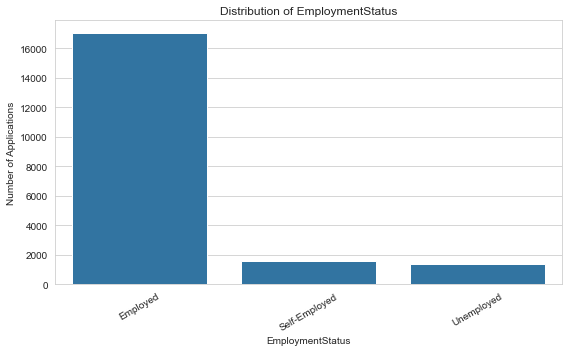

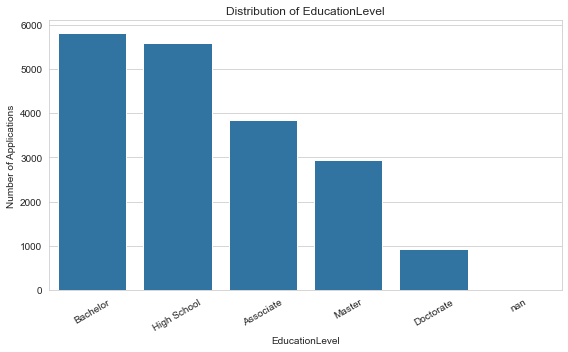

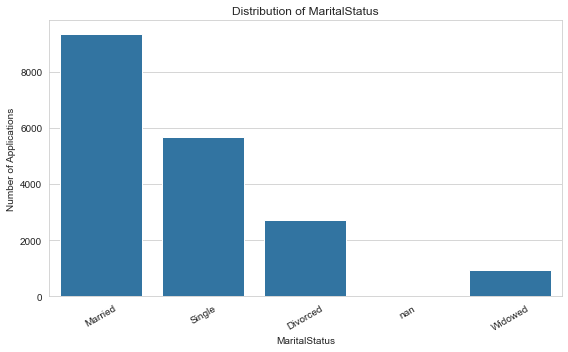

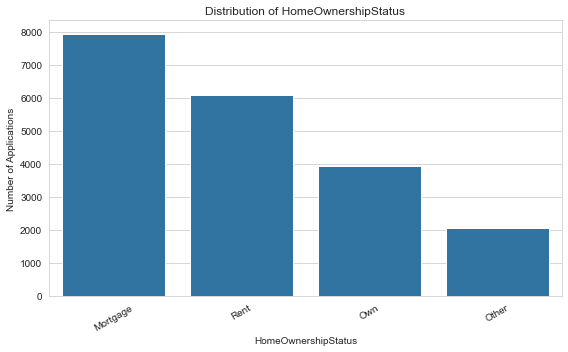

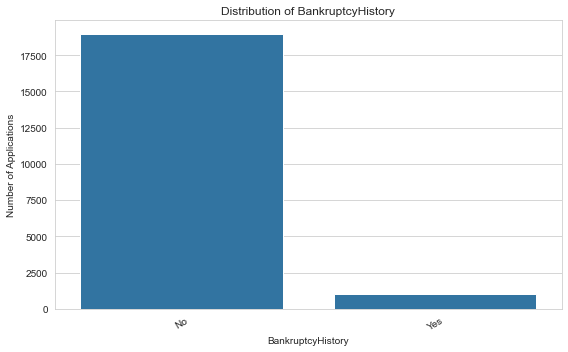

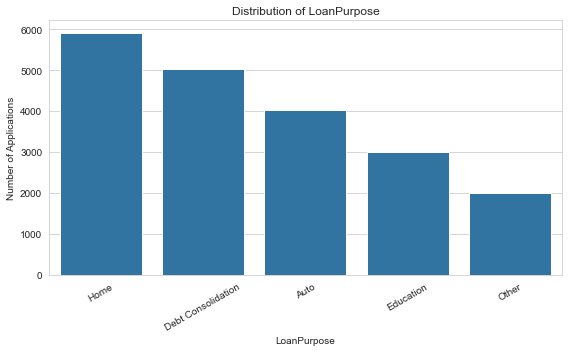

In [23]:
# Plot distributions of categorical features

for column in categorical_features:
    plt.figure(figsize=(8, 5))
    
    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts(dropna=False).index
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Applications")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### Observations from Categorical Feature Distributions

The categorical variables show differences in the number of applications across their respective categories.

`EmploymentStatus` is dominated by employed applicants, while self-employed and unemployed applicants represent smaller groups. `EducationLevel` is mainly composed of applicants with Bachelor and High School education, with fewer applicants holding a Doctorate. Missing values are also present in this variable.

For `MaritalStatus`, married and single applicants make up the largest groups, while divorced and widowed applicants are less common. Missing values are present and will need to be addressed during preprocessing.

For `HomeOwnershipStatus`, mortgage and rent are the most common categories, followed by own and other forms of ownership.

`BankruptcyHistory` is highly imbalanced, with substantially more applicants reporting no previous bankruptcy than those reporting a bankruptcy history. This imbalance may be relevant when assessing relationships with loan approval.

Finally, `LoanPurpose` contains several categories, with home loans being the most common, followed by debt consolidation, auto, education, and other purposes.

These distributions highlight potential class imbalance within individual categorical features and identify missing values that will need to be handled during preprocessing. Rare categories should also be considered when selecting appropriate encoding strategies.

### Correlation Analysis

Correlation analysis is used to examine relationships between numerical variables and identify groups of features that may contain similar information. Understanding these relationships can help identify potentially important predictors, redundant variables, and possible multicollinearity before model development.

In [24]:
# Calculate correlations among numerical features

correlation_matrix = df[numerical_features].corr()

correlation_matrix

,Age,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
Age,1.000000,0.323243,0.982980,-0.007492,-0.006992,-0.000287,0.015685,-0.001394,-0.001069,-0.002165,0.004438,-0.003684,-0.002487,-0.000139,0.004189,0.010145,0.012210,-0.001197,0.144634,-0.005601,-0.000773,0.014061,-0.238995,-0.202702,-0.021380,-0.111800,-0.164304
CreditScore,0.323243,1.000000,0.327664,-0.010834,-0.000762,-0.014453,0.011153,-0.009650,-0.008780,-0.001928,0.001913,-0.007690,0.004295,0.005217,-0.007539,0.005515,0.001342,-0.006722,0.104796,-0.006838,0.008069,0.001951,-0.722619,-0.598844,-0.063932,-0.115363,-0.240198
Experience,0.982980,0.327664,1.000000,-0.007921,-0.007924,0.000136,0.018629,-0.001751,-0.002143,-0.002905,0.003139,-0.002459,-0.003346,-0.001132,0.005693,0.009292,0.013074,-0.000449,0.145950,-0.006603,-0.000762,0.015049,-0.242871,-0.206252,-0.021691,-0.112825,-0.166496
LoanAmount,-0.007492,-0.010834,-0.007921,1.000000,-0.000436,-0.007005,0.021103,0.000806,0.000769,-0.006239,-0.009577,-0.002352,-0.002811,0.000580,0.003531,0.005408,-0.004238,0.000502,-0.005407,-0.012107,0.005364,-0.003679,0.385663,0.322824,0.780828,0.457175,0.137981
LoanDuration,-0.006992,-0.000762,-0.007924,-0.000436,1.000000,-0.001301,0.000068,-0.006160,0.001489,0.000978,0.001913,0.015646,0.001983,0.013693,0.002316,-0.002832,-0.008297,0.003668,0.003067,-0.010105,0.003635,-0.008779,0.579215,0.487994,-0.385495,-0.213984,0.054550
NumberOfDependents,-0.000287,-0.014453,0.000136,-0.007005,-0.001301,1.000000,-0.002396,0.011544,0.006033,-0.003749,-0.007981,0.006116,0.001281,0.002705,-0.001818,0.002485,-0.006284,0.009942,-0.000414,0.008735,0.010910,-0.008423,0.006977,0.006749,-0.001390,-0.000358,0.001686
MonthlyDebtPayments,0.015685,0.011153,0.018629,0.021103,0.000068,-0.002396,1.000000,0.005420,0.006280,0.009889,0.001205,0.002713,-0.003347,-0.004115,-0.005157,0.001909,0.003070,-0.004211,-0.000356,0.001638,0.005863,0.004430,0.000010,0.003895,0.018021,0.219453,0.036938
CreditCardUtilizationRate,-0.001394,-0.009650,-0.001751,0.000806,-0.006160,0.011544,0.005420,1.000000,0.001491,0.001708,0.002231,-0.004450,0.004517,0.007446,0.003183,-0.002115,-0.005047,-0.007778,-0.009381,0.013040,-0.006979,-0.003506,0.003668,0.001030,0.004366,0.010490,0.108758
NumberOfOpenCreditLines,-0.001069,-0.008780,-0.002143,0.000769,0.001489,0.006033,0.006280,0.001491,1.000000,0.000446,0.004363,0.012600,0.002388,0.003653,0.007906,-0.005282,-0.003896,-0.008406,-0.008050,-0.010497,0.007298,-0.002013,0.007457,0.008090,-0.005058,0.003471,0.007762
NumberOfCreditInquiries,-0.002165,-0.001928,-0.002905,-0.006239,0.000978,-0.003749,0.009889,0.001708,0.000446,1.000000,0.005453,-0.006415,-0.004148,-0.003407,-0.004069,-0.004238,0.006784,0.000141,-0.005155,0.005488,0.002794,0.004829,-0.000409,-0.005468,-0.003395,-0.002913,0.003103


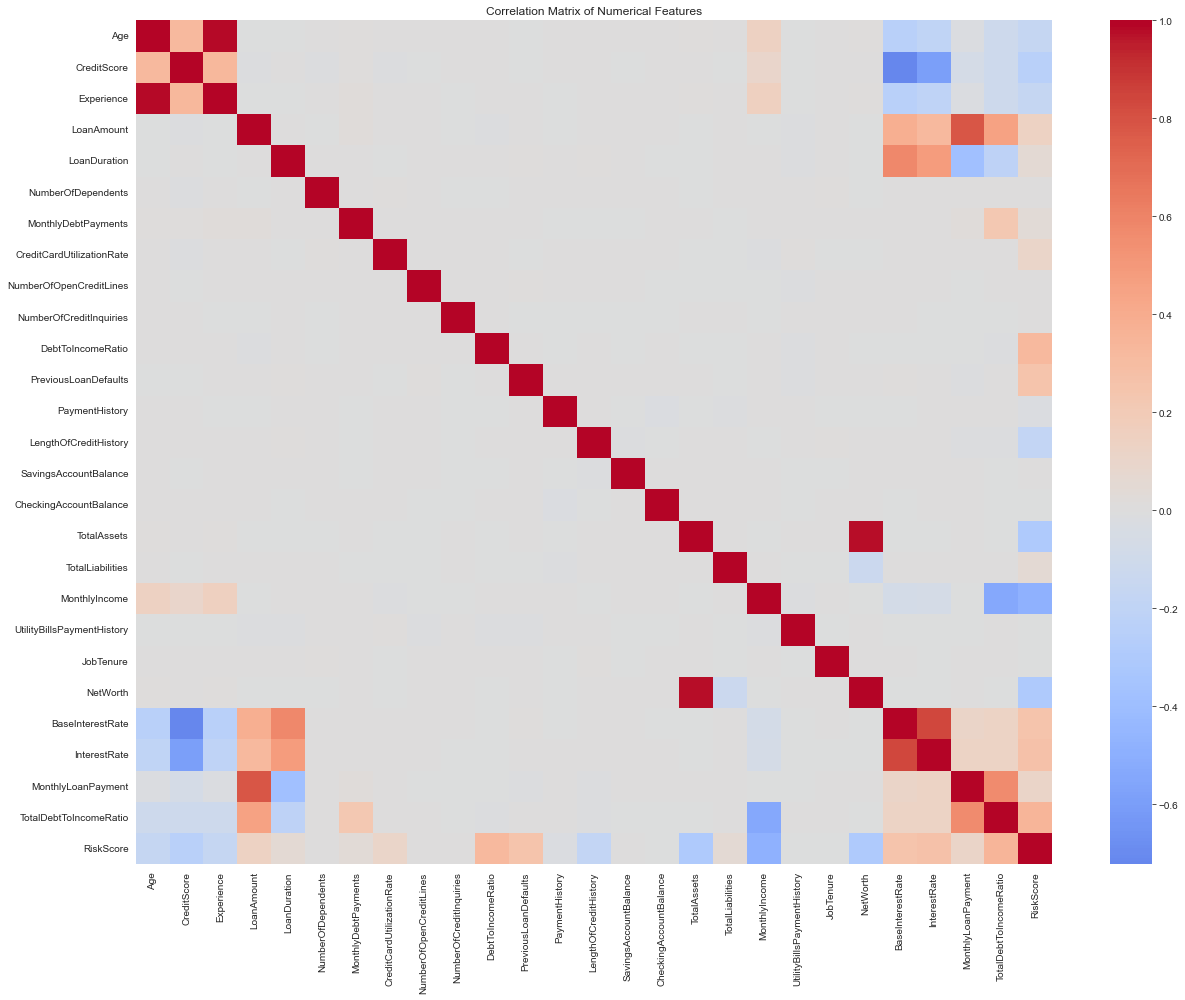

In [25]:
# Visualize correlations among numerical features

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### Interpretation of the Correlation Matrix

The correlation matrix reveals several strong relationships among the numerical variables. `Age` and `Experience` have a very strong positive correlation, while `TotalAssets` and `NetWorth` are also highly correlated. Strong relationships are also observed between `BaseInterestRate` and `InterestRate`, and between `LoanAmount` and `MonthlyLoanPayment`.

A strong negative relationship is observed between `CreditScore` and `BaseInterestRate`, indicating that applicants with higher credit scores tend to have lower base interest rates in this dataset.

These strong correlations indicate potential multicollinearity and overlapping information among some predictors. This will be considered during preprocessing and model development. However, correlation alone does not establish causation, so these relationships should not be interpreted as causal effects.

### Credit Score and Loan Approval

Credit score is an important credit-related variable that may differ between approved and non-approved applications. Comparing its distribution across the two loan approval groups can help determine whether credit score provides useful information for predicting loan approval.

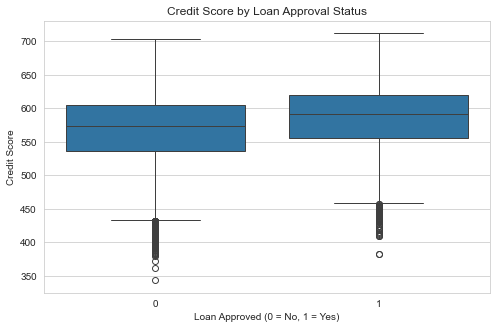

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="LoanApproved",
    y="CreditScore"
)

plt.title("Credit Score by Loan Approval Status")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Credit Score")
plt.show()

### Interpretation: Credit Score and Loan Approval

The boxplot shows that approved applications generally have higher credit scores than non-approved applications. The median credit score is higher for applicants whose loans were approved, although there is substantial overlap between the two groups.

Both approval groups contain lower-score outliers. This indicates that credit score may provide useful information for predicting loan approval, but it is unlikely to be sufficient as a standalone predictor.

The observed relationship represents an association within the dataset and should not be interpreted as evidence that credit score alone causes a loan approval decision.

### Loan Amount and Loan Approval

Loan amount represents the amount of credit requested by an applicant. Comparing loan amounts across approval outcomes can help determine whether the size of the requested loan is associated with historical approval decisions.

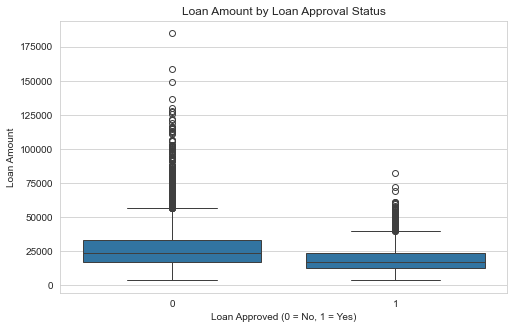

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="LoanApproved",
    y="LoanAmount"
)

plt.title("Loan Amount by Loan Approval Status")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Loan Amount")

plt.show()

### Interpretation: Loan Amount and Loan Approval

The boxplot shows that non-approved applications generally have higher loan amounts than approved applications. The median loan amount is higher for the non-approved group, and the non-approved group also contains substantially more extreme high-value observations.

This suggests that loan amount is associated with historical loan approval decisions. The large number of high-value observations also highlights the importance of considering outliers and skewed distributions during preprocessing and model development.

The relationship is observational and does not establish that a larger loan amount directly causes an application to be rejected.

### Risk Score and Loan Approval

RiskScore is a numerical measure included in the dataset. Its relationship with the historical loan approval outcome will be examined to determine whether risk score differs between approved and non-approved applications and whether it may provide useful predictive information.

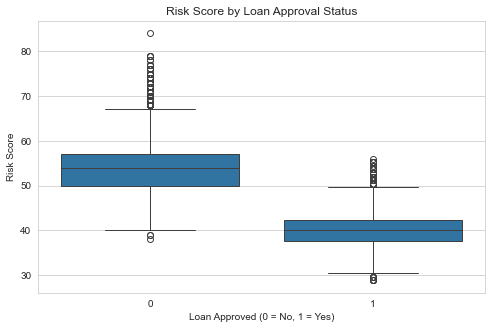

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="LoanApproved",
    y="RiskScore"
)

plt.title("Risk Score by Loan Approval Status")
plt.xlabel("Loan Approved (0 = No, 1 = Yes)")
plt.ylabel("Risk Score")

plt.show()

### Interpretation: Risk Score and Loan Approval

The boxplot shows a clear difference in RiskScore between the two loan approval groups. Non-approved applications have a substantially higher median RiskScore, while approved applications have a lower median RiskScore. The distributions show relatively limited overlap compared with the CreditScore comparison.

This indicates that RiskScore has a strong association with historical loan approval decisions and may be an important predictor of the target.

Before including RiskScore in the final model, its definition and timing should be verified. In particular, we need to confirm that the score is calculated using information available at the time of the loan application and does not incorporate the loan approval outcome or other post-decision information. This check is necessary to avoid data leakage.

### Employment Status and Loan Approval

Approval rates are compared across employment-status categories to determine whether historical loan approval outcomes differ between employed, self-employed, and unemployed applicants. Comparing rates rather than only application counts allows us to account for differences in the size of each group.

In [29]:
# Calculate loan approval rate by employment status

approval_by_employment = (
    df.groupby("EmploymentStatus")["LoanApproved"]
    .mean()
    .sort_values(ascending=False)
)

approval_by_employment

EmploymentStatus
Self-Employed    0.278449
Employed         0.240021
Unemployed       0.181884
Name: LoanApproved, dtype: float64

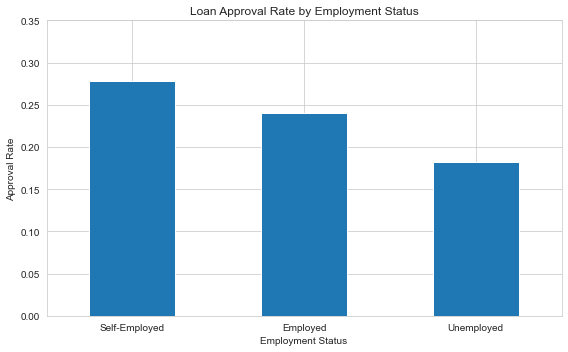

In [30]:
plt.figure(figsize=(8, 5))

approval_by_employment.plot(kind="bar")

plt.title("Loan Approval Rate by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Approval Rate")
plt.ylim(0, 0.35)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Interpretation: Employment Status and Loan Approval

The approval rates differ across employment-status groups. Self-employed applicants have the highest historical approval rate at approximately 27.8%, followed by employed applicants at approximately 24.0%. Unemployed applicants have the lowest approval rate at approximately 18.2%.

These differences indicate that employment status may contain useful information for predicting loan approval. However, the differences should be interpreted as associations within the historical dataset rather than evidence that employment status directly causes approval decisions.

In [31]:
# Calculate approval rates across the remaining categorical features

categorical_approval_rates = {}

for column in categorical_features:
    if column != "EmploymentStatus":
        categorical_approval_rates[column] = (
            df.groupby(column)["LoanApproved"]
            .mean()
            .sort_values(ascending=False)
        )

categorical_approval_rates

{'EducationLevel': EducationLevel
 Doctorate      0.456522
 Master         0.364814
 Bachelor       0.277912
 Associate      0.214026
 High School    0.152539
 Name: LoanApproved, dtype: float64,
 'MaritalStatus': MaritalStatus
 Divorced    0.244822
 Single      0.239541
 Married     0.237033
 Widowed     0.230108
 Name: LoanApproved, dtype: float64,
 'HomeOwnershipStatus': HomeOwnershipStatus
 Mortgage    0.251543
 Own         0.248857
 Rent        0.227698
 Other       0.204813
 Name: LoanApproved, dtype: float64,
 'BankruptcyHistory': BankruptcyHistory
 No     0.246095
 Yes    0.110687
 Name: LoanApproved, dtype: float64,
 'LoanPurpose': LoanPurpose
 Education             0.252992
 Auto                  0.242687
 Home                  0.237975
 Debt Consolidation    0.235130
 Other                 0.223330
 Name: LoanApproved, dtype: float64}

### Categorical Features and Loan Approval Rates

Approval rates were compared across categorical features to identify whether historical loan approval outcomes vary across applicant groups. Education level and bankruptcy history show more noticeable differences in approval rates, while marital status, home ownership, and loan purpose show relatively smaller differences.

These comparisons provide additional insight into potentially useful categorical predictors while also highlighting groups that may require careful consideration during model evaluation.

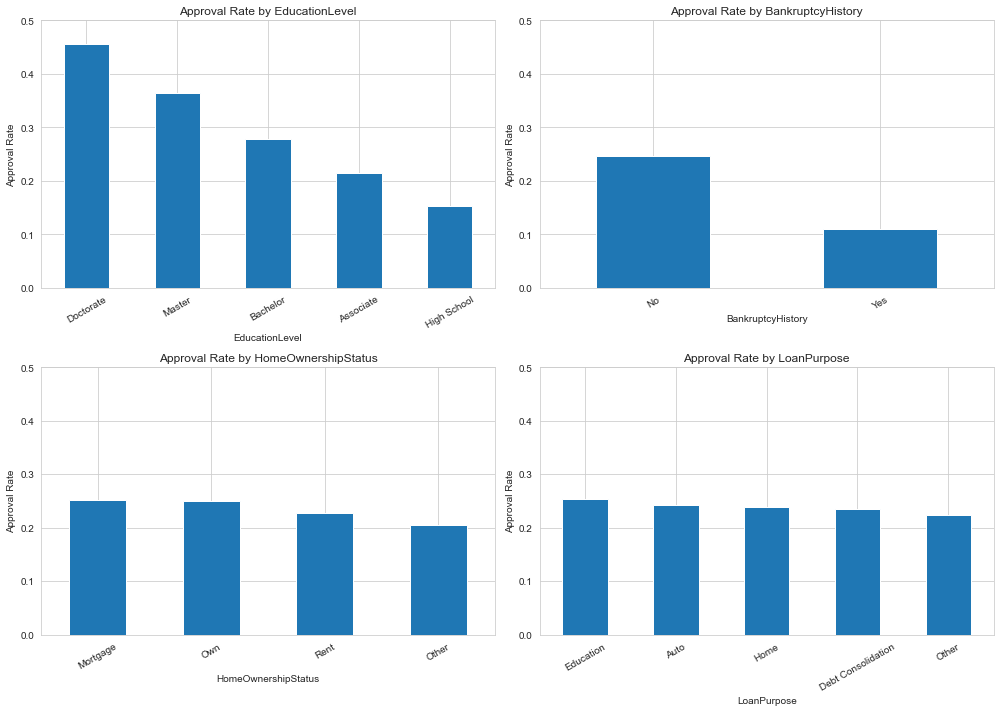

In [32]:
# Compare approval rates across selected categorical features

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

selected_features = [
    "EducationLevel",
    "BankruptcyHistory",
    "HomeOwnershipStatus",
    "LoanPurpose"
]

for ax, column in zip(axes.flatten(), selected_features):
    approval_rate = (
        df.groupby(column)["LoanApproved"]
        .mean()
        .sort_values(ascending=False)
    )
    
    approval_rate.plot(
        kind="bar",
        ax=ax
    )
    
    ax.set_title(f"Approval Rate by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Approval Rate")
    ax.set_ylim(0, 0.5)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Interpretation of Categorical Approval Rates

The categorical approval-rate analysis shows that the magnitude of differences varies across features. Education level shows the largest variation in historical approval rates, while bankruptcy history also shows a noticeable difference between applicants with and without a reported bankruptcy history.

Home ownership status shows smaller differences across its categories, and loan purpose has relatively similar approval rates across categories.

These findings suggest that some categorical variables may provide more predictive information than others. However, the observed differences are based on historical associations and should be evaluated alongside other predictors in the final model.

### Multivariate Analysis Using a Pair Plot

A pair plot is used to examine relationships among selected numerical variables and to compare how these relationships differ between approved and non-approved applications.

A focused set of credit, risk, loan, and debt-related variables is used to keep the visualization interpretable while examining multiple relationships simultaneously.

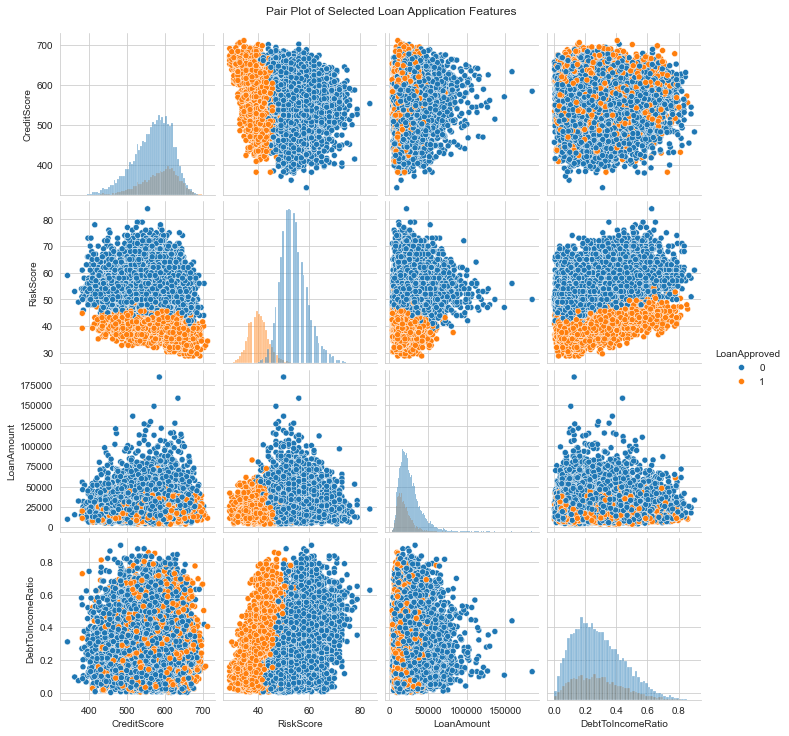

In [33]:
# Select important variables for multivariate analysis

pairplot_features = [
    "CreditScore",
    "RiskScore",
    "LoanAmount",
    "DebtToIncomeRatio",
    "LoanApproved"
]

sns.pairplot(
    df[pairplot_features],
    hue="LoanApproved",
    diag_kind="hist"
)

plt.suptitle(
    "Pair Plot of Selected Loan Application Features",
    y=1.02
)

plt.show()

### Interpretation: Multivariate Relationships

The pair plot provides a multivariate view of selected credit, risk, loan, and debt-related variables.

The clearest separation between loan approval groups is observed for `RiskScore`. Approved applications are concentrated at lower risk-score values, while non-approved applications are more concentrated at higher risk-score values. `CreditScore` also shows differences between the groups, although there is considerable overlap.

`LoanAmount` remains strongly right-skewed and contains several extreme observations. `DebtToIncomeRatio` shows substantial overlap between the approval groups, suggesting that it may provide useful information when combined with other predictors rather than acting as a standalone separator.

Overall, the multivariate analysis indicates that several features may contribute useful predictive information, while also highlighting skewness, outliers, and potential relationships among predictors that should be considered during preprocessing and modeling.

### Outlier Analysis

The distribution plots and boxplots indicate that several financial variables contain extreme observations. The Interquartile Range (IQR) method is used to quantify potential outliers.

An observation is considered a potential outlier when it falls below:

**Q1 − 1.5 × IQR**

or above:

**Q3 + 1.5 × IQR**

These observations will not automatically be removed. Extreme financial values may represent genuine applicants and therefore should be considered carefully during preprocessing and model development.

In [34]:
# Identify potential outliers using the IQR method

outlier_summary = []

for column in numerical_features:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()
    
    outlier_summary.append({
        "Feature": column,
        "Outlier Count": outliers,
        "Outlier Percentage": (outliers / len(df)) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    "Outlier Percentage",
    ascending=False
)

,Feature,Outlier Count,Outlier Percentage
11,PreviousLoanDefaults,2001,10.005
21,NetWorth,1564,7.820
14,SavingsAccountBalance,1547,7.735
17,TotalLiabilities,1533,7.665
15,CheckingAccountBalance,1522,7.610
16,TotalAssets,1442,7.210
25,TotalDebtToIncomeRatio,1152,5.760
24,MonthlyLoanPayment,1089,5.445
18,MonthlyIncome,925,4.625
3,LoanAmount,746,3.730


### Interpretation of Outlier Analysis

The IQR analysis identifies potential outliers across several financial variables. The highest proportions occur in `SavingsAccountBalance`, `TotalLiabilities`, `CheckingAccountBalance`, and `TotalAssets`. `TotalDebtToIncomeRatio`, `MonthlyLoanPayment`, and `MonthlyIncome` also contain notable proportions of potential outliers.

These observations are consistent with the strong right-skewness observed in the numerical distributions. The potential outliers will not be automatically removed because extreme financial values may represent genuine applicants. Instead, their impact will be considered when selecting preprocessing and modeling approaches.

The outlier analysis therefore highlights the need for robust preprocessing while preserving potentially meaningful financial information.

### Feature Types and Preprocessing Considerations

The dataset contains several types of predictors that require different preprocessing approaches.

**Numerical features** include variables such as `Age`, `CreditScore`, `LoanAmount`, `MonthlyIncome`, and `RiskScore`. These variables may require imputation for missing values and scaling for models that are sensitive to feature magnitude.

**Categorical features** include `EmploymentStatus`, `EducationLevel`, `MaritalStatus`, `HomeOwnershipStatus`, `BankruptcyHistory`, and `LoanPurpose`. These variables require missing-value handling and categorical encoding before they can be used by most machine-learning algorithms.

`EducationLevel` has an inherent educational ordering, so it can be treated as an ordinal variable if an appropriate ordinal encoding is justified. The remaining categorical variables are nominal and do not have a natural numerical order.

`AnnualIncome` is currently stored as a text variable even though it represents a numerical monetary value. It will therefore require conversion to a numerical format during data preparation.

The analysis also identified missing values in `EducationLevel`, `MaritalStatus`, and `SavingsAccountBalance`, as well as potential outliers and strong correlations among some numerical variables. These issues will be addressed systematically using preprocessing pipelines rather than manual modifications to the original dataset.

## Data Understanding Summary

The exploratory analysis identified several important characteristics of the loan application dataset.

The target variable, `LoanApproved`, is imbalanced, with approved applications representing 23.9% of observations and non-approved applications representing 76.1%. This means that accuracy alone may not adequately describe model performance.

The numerical analysis revealed substantial skewness and potential outliers in several financial variables. Strong correlations were also identified between pairs such as `Age` and `Experience`, `TotalAssets` and `NetWorth`, and `BaseInterestRate` and `InterestRate`, indicating potential multicollinearity.

Categorical analysis showed differences in historical approval rates across employment status, education level, home ownership, bankruptcy history, and loan purpose. Missing values were identified in several features and will need to be handled during preprocessing.

The analysis also found a substantial difference in `RiskScore` between approved and non-approved applications. Before using this variable for modeling, its definition and availability at the time of the loan decision should be verified to reduce the risk of data leakage.

These findings provide the basis for the next stage of the CRISP-DM process: **Data Preparation**. The next stage will address missing values, data types, categorical encoding, numerical scaling, and feature-processing decisions using reproducible machine-learning pipelines.

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



### Separating Predictors and Target

The target variable for this classification problem is `LoanApproved`. The remaining variables will be used as predictors.

The dataset will be divided into training and testing sets before preprocessing. This prevents information from the test set from influencing the preprocessing steps used to train the model.

Stratification will be used because the target variable is imbalanced. This ensures that the proportion of approved and non-approved applications is approximately preserved in both the training and testing sets.

### Separating Predictors and Target

The target variable for this classification problem is `LoanApproved`. The remaining variables will be used as predictors.

Separating the target from the predictors before preprocessing helps prevent the target variable from being accidentally transformed or used as an input feature.

In [35]:
# Separate predictors and target

X = df.drop(columns=["LoanApproved"])
y = df["LoanApproved"]

X.shape, y.shape

((20000, 34), (20000,))

### Splitting the Data into Training and Testing Sets

The dataset is divided into training and testing sets using an 80/20 split. The training data will be used to develop and tune the models, while the test data will be reserved for final evaluation.

Stratified sampling is used because the target variable is imbalanced. This helps maintain a similar proportion of approved and non-approved applications in both datasets.

A fixed random state is used to make the results reproducible.

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16000, 34), (4000, 34), (16000,), (4000,))

### Defining Feature Groups

The predictor variables are separated according to their data types and preprocessing requirements.

Numerical features will be imputed and scaled. `EducationLevel` is treated as an ordinal feature because its categories have a natural order. The remaining categorical variables are treated as nominal features because their categories do not have a meaningful numerical order.

`AnnualIncome` is currently stored as a currency-formatted text variable, so it requires a separate cleaning step before numerical preprocessing.

`RiskScore` is temporarily excluded from the numerical pipeline because its timing and relationship to the loan approval decision should be verified before it is used as a predictor.

In [37]:
# Define feature groups for preprocessing

numeric_features = [
    column for column in numerical_features
    if column not in ["RiskScore"]
]

numeric_features.append("AnnualIncome")

ordinal_features = ["EducationLevel"]

categorical_features_for_pipeline = [
    "EmploymentStatus",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "BankruptcyHistory",
    "LoanPurpose"
]

print("Numerical features:", len(numeric_features))
print("Ordinal features:", ordinal_features)
print("Categorical features:", categorical_features_for_pipeline)

Numerical features: 27
Ordinal features: ['EducationLevel']
Categorical features: ['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


### Preprocessing Tools

Scikit-learn preprocessing tools will be used to create a consistent and reproducible preprocessing workflow.

The workflow will include missing-value imputation, numerical scaling, categorical encoding, and transformation of the currency-formatted `AnnualIncome` variable.

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

### Cleaning Annual Income

`AnnualIncome` is stored as text containing dollar signs and commas, even though it represents a numerical monetary value.

The currency symbols and comma separators will therefore be removed, and the resulting values will be converted to numeric values.

This transformation will be included in the preprocessing pipeline so that the same procedure is consistently applied to the training and testing data.

In [39]:
def clean_annual_income(X):
    X = pd.DataFrame(X, columns=["AnnualIncome"]).copy()
    
    X["AnnualIncome"] = (
        X["AnnualIncome"]
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
    )
    
    return X.astype(float)


### Numerical Feature Pipeline

Numerical features will be processed using two steps.

First, missing numerical values will be replaced using the median. Median imputation is appropriate because the exploratory analysis identified potential outliers in several financial variables.

Second, numerical features will be standardized using `StandardScaler`. Scaling is particularly useful for models such as logistic regression because it places variables with different units and ranges on a comparable scale.

In [40]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### Annual Income Preprocessing Pipeline

`AnnualIncome` requires a separate preprocessing pipeline because it is initially stored as a currency-formatted text variable.

The pipeline first removes the currency formatting, then handles missing values using median imputation, and finally standardizes the resulting numerical values.

In [41]:
annual_income_pipeline = Pipeline(steps=[
    ("clean_currency", FunctionTransformer(clean_annual_income)),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### Ordinal Categorical Feature Pipeline

`EducationLevel` is treated as an ordinal categorical variable because its categories have a meaningful order.

The categories are explicitly ordered from `High School` to `Doctorate` so that the encoding preserves the increasing level of educational attainment.

Missing values are replaced using the most frequent category before the values are ordinally encoded.

In [42]:
ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        categories=[[
            "High School",
            "Associate",
            "Bachelor",
            "Master",
            "Doctorate"
        ]]
    ))
])

### Nominal Categorical Feature Pipeline

The nominal categorical features are `EmploymentStatus`, `MaritalStatus`, `HomeOwnershipStatus`, `BankruptcyHistory`, and `LoanPurpose`.

These variables do not have a natural numerical order, so they will be encoded using One-Hot Encoding rather than ordinal encoding. Missing categorical values will be replaced using the most frequent category.

`handle_unknown="ignore"` is used so that the pipeline can safely process categories that may appear in the test data but were not present in the training data.

In [43]:
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

### Combining Preprocessing Steps with ColumnTransformer

The different feature types require different preprocessing procedures. A `ColumnTransformer` will combine these separate preprocessing pipelines into one unified transformation.

Numerical features will use median imputation and standardization, `AnnualIncome` will undergo currency cleaning followed by numerical preprocessing, `EducationLevel` will use ordinal encoding, and the remaining categorical variables will use one-hot encoding.

Using a single `ColumnTransformer` helps ensure that the same preprocessing steps are applied consistently to the training and testing data and reduces the risk of data leakage.

In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, [
            column for column in numeric_features
            if column != "AnnualIncome"
        ]),
        ("annual_income", annual_income_pipeline, ["AnnualIncome"]),
        ("ordinal", ordinal_pipeline, ordinal_features),
        ("categorical", categorical_pipeline, categorical_features_for_pipeline)
    ]
)

### Fitting and Testing the Preprocessing Pipeline

The preprocessing transformer will now be fitted using only the training data and then used to transform the training features.

Fitting the preprocessing steps only on the training data is important for preventing data leakage. For example, the median values used for imputation and the means and standard deviations used for scaling should be learned from the training data rather than from the test data.

The transformed training data will also be checked to confirm that the preprocessing pipeline works correctly.

In [45]:
X_train_transformed = preprocessor.fit_transform(X_train)

X_train_transformed.shape

(16000, 46)

### Transforming the Test Data

The fitted preprocessing transformer will now be applied to the test data.

The transformer is not fitted again on the test set. Instead, it uses the preprocessing rules learned from the training data. This prevents information from the test set from influencing the preprocessing stage and helps maintain a valid evaluation of model performance.

In [46]:
X_test_transformed = preprocessor.transform(X_test)

X_test_transformed.shape

(4000, 46)

### Preprocessing Validation

The preprocessing pipeline successfully transformed both datasets. The training set contains 16,000 observations and the test set contains 4,000 observations, with 46 transformed features in each dataset.

The matching number of transformed features confirms that the preprocessing structure is consistent between the training and test sets. The test set was transformed using parameters learned from the training data, helping prevent data leakage.

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


### Modeling Approach

The modeling stage will compare multiple classification algorithms for predicting `LoanApproved`.

Because the business problem involves asymmetric financial consequences for incorrect decisions, model evaluation will not rely on accuracy alone. Precision, recall, ROC-AUC, and the estimated business cost of classification errors will be considered.

Multiple algorithms will be evaluated using the same preprocessing framework to ensure a fair comparison. Cross-validation will be used during model development to obtain more reliable estimates of model performance.

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

### Logistic Regression Baseline Model

Logistic Regression will be used as the first baseline classification model because `LoanApproved` is a binary target.

The model is also useful as an interpretable benchmark because its coefficients can provide information about how the predictors are associated with the probability of loan approval.

The preprocessing transformer will be included directly in the modeling pipeline. This ensures that preprocessing is consistently applied whenever the model is trained or used to make predictions and helps prevent data leakage.

The baseline model will provide a reference point against which more complex classification algorithms can be compared.

In [48]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

### Training the Logistic Regression Model

The Logistic Regression pipeline will now be fitted using the training data.

Because the preprocessing steps are contained inside the pipeline, the model will learn the required imputation, encoding, and scaling parameters from the training data during fitting.

The test data will not be used during this training stage. It will remain unseen until final model evaluation.

In [49]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'CreditScore',
                                                   'Experience', 'LoanAmount',
                                                   'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
                                                   'NumberOfCreditInquiries'...
                                                                                               'Bachelor',
                                                                                               'Master',
                                                                                               'Doctorate']]))]),
                                                  ['EducationLevel']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['EmploymentStatus',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

### Generating Test Set Predictions

The trained Logistic Regression pipeline will be used to generate predictions for the unseen test data.

The pipeline automatically applies the same preprocessing steps learned from the training data before making predictions. This allows us to evaluate how well the model generalizes to new loan applications.

In [50]:
y_pred_logistic = logistic_pipeline.predict(X_test)

y_pred_logistic[:10]

array([0, 0, 1, 0, 0, 1, 0, 0, 1, 0], dtype=int64)

### Evaluating the Logistic Regression Baseline

The Logistic Regression predictions will now be compared with the actual outcomes in the test set.

Several metrics will be calculated to provide a balanced view of model performance. Accuracy measures the overall proportion of correct predictions, while precision and recall provide more detailed information about the model's performance on the approved class.

ROC-AUC will also be calculated using the model's predicted probabilities. This measures the model's ability to distinguish between approved and non-approved applications across different classification thresholds.

In [54]:
y_proba_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_roc_auc = roc_auc_score(y_test, y_proba_logistic)

print("Logistic Regression Results")
print(f"Accuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"ROC-AUC:   {logistic_roc_auc:.4f}")

Logistic Regression Results
Accuracy:  0.9665
Precision: 0.9335
Recall:    0.9257
ROC-AUC:   0.9946


### Confusion Matrix Analysis

The confusion matrix will be used to examine the four types of classification outcomes: true positives, true negatives, false positives, and false negatives.

This is particularly important for the loan approval problem because false positives and false negatives have different financial consequences.

A false positive occurs when the model predicts that an application should be approved when the actual outcome is not approved. A false negative occurs when the model predicts that an application should not be approved when the actual outcome is approved.

The confusion matrix will therefore provide the counts needed to calculate the potential business cost of model errors.

In [55]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

cm_logistic

array([[2981,   63],
       [  71,  885]], dtype=int64)

### Financial Impact of Logistic Regression Errors

The confusion matrix allows the model's classification errors to be translated into estimated financial consequences.

For this business problem, a false negative represents a creditworthy applicant who is not approved, resulting in an estimated opportunity cost of $8,000.

A false positive represents an applicant who is approved but subsequently represents a bad loan, resulting in an estimated loss of $50,000.

Using the observed test-set errors, the estimated business cost is calculated as:

**Business Cost = (False Negatives × $8,000) + (False Positives × $50,000)**

This provides a business-focused measure that complements the standard classification metrics.

In [56]:
tn, fp, fn, tp = cm_logistic.ravel()

false_negative_cost = fn * 8000
false_positive_cost = fp * 50000

total_business_cost = false_negative_cost + false_positive_cost

print(f"False Negative Cost: ${false_negative_cost:,.0f}")
print(f"False Positive Cost: ${false_positive_cost:,.0f}")
print(f"Total Estimated Business Cost: ${total_business_cost:,.0f}")

False Negative Cost: $568,000
False Positive Cost: $3,150,000
Total Estimated Business Cost: $3,718,000


### Business Interpretation of Logistic Regression Errors

The Logistic Regression model produced 71 false negatives and 63 false positives on the 4,000 applicant test set.

The estimated cost of false negatives is $568,000, while the estimated cost of false positives is $3,150,000. The total estimated cost of these classification errors is therefore $3,718,000.

Although there are slightly more false negatives than false positives, false positives contribute substantially more to the total financial cost because each false positive carries an estimated loss of $50,000 compared with $8,000 for each false negative.

This demonstrates why model evaluation should consider the financial consequences of errors rather than relying on accuracy alone. The results also indicate that the classification threshold may be an important consideration when balancing approval decisions against financial risk.

### Decision Tree Classification Model

A Decision Tree Classifier will be evaluated as a second classification approach.

Unlike Logistic Regression, a decision tree can capture nonlinear relationships and interactions between predictors. It also provides a relatively interpretable structure through decision rules and feature importance.

The same preprocessing pipeline will be used so that the comparison with Logistic Regression is based on the same transformed input data.

A maximum tree depth will initially be specified to help control model complexity and reduce the risk of overfitting. The appropriate hyperparameters will be investigated later during model tuning.

In [57]:
decision_tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ))
])

### Training the Decision Tree

The Decision Tree pipeline will now be fitted using the training data.

The preprocessing steps will be learned from the training set as part of the pipeline, and the decision tree will then learn classification rules for predicting `LoanApproved`.

The test data will remain unseen during training so that it can be used later for an unbiased performance evaluation.

In [58]:
decision_tree_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'CreditScore',
                                                   'Experience', 'LoanAmount',
                                                   'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
                                                   'NumberOfCreditInquiries'...
                                                                                               'Bachelor',
                                                                                               'Master',
                                                                                               'Doctorate']]))]),
                                                  ['EducationLevel']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['EmploymentStatus',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=10, random_state=42))])

### Generating Decision Tree Test Predictions

The trained Decision Tree pipeline will now be used to predict loan approval outcomes for the unseen test set.

The same preprocessing steps learned during training will automatically be applied before generating the predictions.

In [59]:
y_pred_tree = decision_tree_pipeline.predict(X_test)

y_pred_tree[:10]

array([0, 1, 1, 0, 0, 1, 0, 0, 1, 0], dtype=int64)

### Evaluating the Decision Tree

The Decision Tree predictions will be evaluated using the same metrics used for Logistic Regression: accuracy, precision, recall, and ROC-AUC.

Using the same evaluation measures allows the two models to be compared consistently. The predicted probabilities will be used for ROC-AUC because this metric evaluates the model's ability to distinguish between approved and non-approved applications across different classification thresholds.

In [60]:
y_proba_tree = decision_tree_pipeline.predict_proba(X_test)[:, 1]

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_roc_auc = roc_auc_score(y_test, y_proba_tree)

print("Decision Tree Results")
print(f"Accuracy:  {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall:    {tree_recall:.4f}")
print(f"ROC-AUC:   {tree_roc_auc:.4f}")

Decision Tree Results
Accuracy:  0.8950
Precision: 0.7780
Recall:    0.7845
ROC-AUC:   0.8839


### Decision Tree Confusion Matrix

The Decision Tree confusion matrix will be examined to identify the numbers of true positives, true negatives, false positives, and false negatives.

These error counts will allow us to calculate the estimated financial cost of the Decision Tree's incorrect loan approval decisions using the business cost assumptions established earlier.

In [61]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

cm_tree

array([[2830,  214],
       [ 206,  750]], dtype=int64)

### Financial Impact of Decision Tree Errors

The Decision Tree produced 214 false positives and 206 false negatives on the test set.

Using the business cost assumptions, each false positive represents an estimated loss of $50,000, while each false negative represents an estimated opportunity cost of $8,000.

The total estimated business cost will therefore be calculated from both types of errors. Comparing this cost with the Logistic Regression baseline will help demonstrate why financial impact is an important consideration when selecting a loan approval model.

In [62]:
tn_tree, fp_tree, fn_tree, tp_tree = cm_tree.ravel()

tree_false_negative_cost = fn_tree * 8000
tree_false_positive_cost = fp_tree * 50000

tree_total_business_cost = (
    tree_false_negative_cost + tree_false_positive_cost
)

print(f"False Negative Cost: ${tree_false_negative_cost:,.0f}")
print(f"False Positive Cost: ${tree_false_positive_cost:,.0f}")
print(f"Total Estimated Business Cost: ${tree_total_business_cost:,.0f}")

False Negative Cost: $1,648,000
False Positive Cost: $10,700,000
Total Estimated Business Cost: $12,348,000


### Baseline Model Comparison

The Logistic Regression and Decision Tree models show different levels of performance on the test set.

Logistic Regression achieved higher accuracy, precision, recall, and ROC-AUC than the Decision Tree in this initial comparison. It also produced fewer false positives and false negatives, resulting in a lower estimated business cost.

The results demonstrate the importance of evaluating both statistical performance and financial consequences. However, these are baseline models with initial settings, so additional algorithms and hyperparameter tuning are required before drawing conclusions about the final model.

### Random Forest Classification Model

A Random Forest Classifier will be evaluated as a third modeling approach.

Random Forest is an ensemble method that combines predictions from multiple decision trees. This can help capture nonlinear relationships and interactions between features while reducing the dependence on a single tree.

The model will use the same preprocessing pipeline as the previous algorithms so that the comparison remains consistent.

An initial number of trees and maximum tree depth will be specified for this baseline model. These hyperparameters will be tuned later using cross-validation.

In [63]:
random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

### Training the Random Forest Model

The Random Forest pipeline will now be fitted using the training data.

The model will learn from multiple decision trees rather than relying on a single tree. The preprocessing steps remain inside the pipeline and are learned from the training data during fitting.

The test data will remain unseen until the model is evaluated.

In [64]:
random_forest_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'CreditScore',
                                                   'Experience', 'LoanAmount',
                                                   'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
                                                   'NumberOfCreditInquiries'...
                                                                                               'Master',
                                                                                               'Doctorate']]))]),
                                                  ['EducationLevel']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['EmploymentStatus',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, n_jobs=-1,
                                        random_state=42))])

### Generating Random Forest Test Predictions

The trained Random Forest pipeline will now be used to predict loan approval outcomes for the unseen test set.

The pipeline will automatically apply the preprocessing steps learned from the training data before generating the predictions.

In [65]:
y_pred_rf = random_forest_pipeline.predict(X_test)

y_pred_rf[:10]

array([0, 1, 1, 0, 0, 1, 0, 0, 0, 0], dtype=int64)

### Evaluating the Random Forest

The Random Forest predictions will be evaluated using accuracy, precision, recall, and ROC-AUC.

These metrics are kept consistent with the previous models so that their performance can be compared fairly. The predicted probabilities will be used to calculate ROC-AUC.

In [66]:
y_proba_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_proba_rf)

print("Random Forest Results")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

Random Forest Results
Accuracy:  0.9230
Precision: 0.8885
Recall:    0.7751
ROC-AUC:   0.9753


### Random Forest Confusion Matrix

The Random Forest confusion matrix will be examined to identify its true positives, true negatives, false positives, and false negatives.

These error counts will be used to calculate the estimated financial cost of incorrect loan approval decisions. This allows the Random Forest to be compared with the previous models from both a statistical and business perspective.

In [67]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf

array([[2951,   93],
       [ 215,  741]], dtype=int64)

### Financial Impact of Random Forest Errors

The Random Forest produced 93 false positives and 215 false negatives on the test set.

The business cost assumptions assign an estimated loss of $50,000 to each false positive and an estimated opportunity cost of $8,000 to each false negative.

The total estimated business cost will be calculated and compared with the costs of the Logistic Regression and Decision Tree models.

In [68]:
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

rf_false_negative_cost = fn_rf * 8000
rf_false_positive_cost = fp_rf * 50000

rf_total_business_cost = (
    rf_false_negative_cost + rf_false_positive_cost
)

print(f"False Negative Cost: ${rf_false_negative_cost:,.0f}")
print(f"False Positive Cost: ${rf_false_positive_cost:,.0f}")
print(f"Total Estimated Business Cost: ${rf_total_business_cost:,.0f}")

False Negative Cost: $1,720,000
False Positive Cost: $4,650,000
Total Estimated Business Cost: $6,370,000


### Gradient Boosting

Gradient Boosting is added to the baseline comparison because it can capture nonlinear relationships and interactions between predictors that may not be fully captured by linear models.

The model will be evaluated using the same metrics as the previous models: accuracy, precision, recall, ROC-AUC, and estimated business cost. Using the same evaluation framework allows a consistent comparison across models.

In [72]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

In [73]:
gradient_boosting_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'CreditScore',
                                                   'Experience', 'LoanAmount',
                                                   'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
                                                   'NumberOfCreditInquiries'...
                                                                                               'Associate',
                                                                                               'Bachelor',
                                                                                               'Master',
                                                                                               'Doctorate']]))]),
                                                  ['EducationLevel']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['EmploymentStatus',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [74]:
y_pred_gb = gradient_boosting_pipeline.predict(X_test)

y_proba_gb = gradient_boosting_pipeline.predict_proba(X_test)[:, 1]

y_pred_gb[:10]

array([0, 1, 1, 0, 0, 1, 0, 0, 0, 0], dtype=int64)

### Gradient Boosting Evaluation

The Gradient Boosting model is evaluated using accuracy, precision, recall, and ROC-AUC. Its confusion matrix is also used to calculate the estimated business cost based on the provided $8,000 false-negative cost and $50,000 false-positive cost.

In [75]:
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_roc_auc = roc_auc_score(y_test, y_proba_gb)

print("Gradient Boosting Results")
print(f"Accuracy:  {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall:    {gb_recall:.4f}")
print(f"ROC-AUC:   {gb_roc_auc:.4f}")

Gradient Boosting Results
Accuracy:  0.9463
Precision: 0.9076
Recall:    0.8630
ROC-AUC:   0.9866


### Gradient Boosting Business Impact

The confusion matrix is used to identify false positives and false negatives. These errors are converted into estimated financial costs using the business assumptions provided in the case: $8,000 for each false negative and $50,000 for each false positive.

In [76]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

tn_gb, fp_gb, fn_gb, tp_gb = cm_gb.ravel()

gb_false_negative_cost = fn_gb * 8000
gb_false_positive_cost = fp_gb * 50000

gb_total_business_cost = (
    gb_false_negative_cost + gb_false_positive_cost
)

print("Gradient Boosting Confusion Matrix:")
print(cm_gb)

print(f"\nTrue Negatives:  {tn_gb:,}")
print(f"False Positives: {fp_gb:,}")
print(f"False Negatives: {fn_gb:,}")
print(f"True Positives:  {tp_gb:,}")

print(f"\nFalse Negative Cost: ${gb_false_negative_cost:,.0f}")
print(f"False Positive Cost: ${gb_false_positive_cost:,.0f}")
print(f"Total Business Cost: ${gb_total_business_cost:,.0f}")

Gradient Boosting Confusion Matrix:
[[2960   84]
 [ 131  825]]

True Negatives:  2,960
False Positives: 84
False Negatives: 131
True Positives:  825

False Negative Cost: $1,048,000
False Positive Cost: $4,200,000
Total Business Cost: $5,248,000


### K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is included as a fifth classification algorithm to provide another modeling approach for comparison.

KNN classifies an observation based on the classes of nearby observations. Because KNN is distance-based, the numerical features have already been standardized in the preprocessing pipeline.

The model will be evaluated using accuracy, precision, recall, ROC-AUC, and estimated business cost, consistent with the other models.

In [79]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(
        n_neighbors=5,
        weights="distance"
    ))
])

In [80]:
knn_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'CreditScore',
                                                   'Experience', 'LoanAmount',
                                                   'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
                                                   'NumberOfCreditInquiries'...
                                                                                               'Associate',
                                                                                               'Bachelor',
                                                                                               'Master',
                                                                                               'Doctorate']]))]),
                                                  ['EducationLevel']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['EmploymentStatus',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose'])])),
                ('model', KNeighborsClassifier(weights='distance'))])

In [81]:
y_pred_knn = knn_pipeline.predict(X_test)

y_proba_knn = knn_pipeline.predict_proba(X_test)[:, 1]

y_pred_knn[:10]

c:\Users\Maggie\anaconda3\envs\learn-env\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Maggie\anaconda3\envs\learn-env\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\Maggie\anaconda3\envs\learn-env\lib\subprocess.py", line 489, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\Maggie\anaconda3\envs\learn-env\lib\subprocess.py", line 854, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Maggie\anaconda3\envs\learn-env\lib\subprocess.py", line 1307, in _execute_child
    hp, ht, pid, tid = _winap

array([0, 0, 1, 0, 0, 1, 0, 0, 0, 0], dtype=int64)

### KNN Evaluation

The KNN model is evaluated using the same metrics as the other classification models to ensure a fair comparison.

We will calculate accuracy, precision, recall, ROC-AUC, and the estimated business cost. The business cost assigns a higher penalty to false-positive approvals because approving a loan that later defaults has an estimated loss of $50,000, compared with $8,000 for a missed creditworthy applicant.

In [82]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_roc_auc = roc_auc_score(y_test, y_proba_knn)

knn_cm = confusion_matrix(y_test, y_pred_knn)

knn_tn, knn_fp, knn_fn, knn_tp = knn_cm.ravel()

knn_false_negative_cost = knn_fn * 8000
knn_false_positive_cost = knn_fp * 50000

knn_total_business_cost = (
    knn_false_negative_cost +
    knn_false_positive_cost
)

print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall: {knn_recall:.4f}")
print(f"ROC-AUC: {knn_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(knn_cm)

print(f"\nFalse Negative Cost: ${knn_false_negative_cost:,.0f}")
print(f"False Positive Cost: ${knn_false_positive_cost:,.0f}")
print(f"Total Business Cost: ${knn_total_business_cost:,.0f}")

Accuracy: 0.8888
Precision: 0.8297
Recall: 0.6726
ROC-AUC: 0.9307

Confusion Matrix:
[[2912  132]
 [ 313  643]]

False Negative Cost: $2,504,000
False Positive Cost: $6,600,000
Total Business Cost: $9,104,000


### Comparison of Baseline Classification Models

Five classification algorithms were evaluated using the same preprocessing pipeline and test set. Comparing the models using the same metrics provides a consistent basis for assessing predictive performance and business impact.

In addition to conventional classification metrics, estimated business cost is included because the financial consequences of false negatives and false positives are different in this lending problem. This allows model performance to be considered from both a statistical and business perspective.

In [85]:
baseline_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "KNN"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy,
        gb_accuracy,
        knn_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision,
        gb_precision,
        knn_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall,
        gb_recall,
        knn_recall
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        tree_roc_auc,
        rf_roc_auc,
        gb_roc_auc,
        knn_roc_auc
    ],
    "Business Cost": [
        total_business_cost,
        tree_total_business_cost,
        rf_total_business_cost,
        gb_total_business_cost,
        knn_total_business_cost
    ]
})

baseline_results

,Model,Accuracy,Precision,Recall,ROC-AUC,Business Cost
0,Logistic Regression,0.96650,0.933544,0.925732,0.994608,3718000
1,Decision Tree,0.89500,0.778008,0.784519,0.883932,12348000
2,Random Forest,0.92300,0.888489,0.775105,0.975304,6370000
3,Gradient Boosting,0.94625,0.907591,0.862971,0.986615,5248000
4,KNN,0.88875,0.829677,0.672594,0.930674,9104000


In [86]:
baseline_results.copy().assign(
    Accuracy=baseline_results["Accuracy"].map("{:.4f}".format),
    Precision=baseline_results["Precision"].map("{:.4f}".format),
    Recall=baseline_results["Recall"].map("{:.4f}".format),
    **{
        "ROC-AUC": baseline_results["ROC-AUC"].map("{:.4f}".format),
        "Business Cost": baseline_results["Business Cost"].map(
            lambda x: f"${x:,.0f}"
        )
    }
)

,Model,Accuracy,Precision,Recall,ROC-AUC,Business Cost
0,Logistic Regression,0.9665,0.9335,0.9257,0.9946,"$3,718,000"
1,Decision Tree,0.8950,0.7780,0.7845,0.8839,"$12,348,000"
2,Random Forest,0.9230,0.8885,0.7751,0.9753,"$6,370,000"
3,Gradient Boosting,0.9463,0.9076,0.8630,0.9866,"$5,248,000"
4,KNN,0.8888,0.8297,0.6726,0.9307,"$9,104,000"


### Baseline Model Results

Five classification algorithms were implemented as baseline models: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and K-Nearest Neighbors (KNN).

Each model uses the same preprocessing pipeline and is evaluated on the same test set to ensure a consistent comparison. The evaluation includes accuracy, precision, recall, ROC-AUC, and estimated business cost.

Accuracy measures the overall proportion of correct predictions. Precision measures how many predicted approvals were actually approved loans, while recall measures how many of the actual approved loans were correctly identified. ROC-AUC measures the model's ability to distinguish between approved and non-approved applications across different classification thresholds.

Because the financial consequences of errors are asymmetric, business cost is also calculated. A false negative represents a potentially creditworthy applicant who is not approved and has an estimated opportunity cost of $8,000. A false positive represents an approved loan that subsequently defaults and has an estimated loss of $50,000.

The baseline results provide an initial comparison of model performance. Cross-validation and hyperparameter tuning will be performed before selecting the final model.

### Cross-Validation Strategy

The baseline models are next evaluated using 5-fold stratified cross-validation. Stratification is used because the target classes are imbalanced, with approximately 76.1% of applications in the non-approved class and 23.9% in the approved class.

Cross-validation provides a more reliable estimate of model performance than relying on a single train/test split. The same preprocessing and modeling pipelines will be evaluated across the folds to reduce the risk of data leakage.

ROC-AUC is used as the primary cross-validation metric because it evaluates the model's ability to distinguish between the two classes across different classification thresholds.

In [87]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline,
    "KNN": knn_pipeline
}

cv_results = []

for model_name, model_pipeline in models.items():
    scores = cross_val_score(
        model_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )
    
    cv_results.append({
        "Model": model_name,
        "Mean ROC-AUC": scores.mean(),
        "Std ROC-AUC": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,Mean ROC-AUC,Std ROC-AUC
0,Logistic Regression,0.994625,0.000927
1,Decision Tree,0.891143,0.008782
2,Random Forest,0.973458,0.003796
3,Gradient Boosting,0.985227,0.002143
4,KNN,0.919842,0.008943


### Cross-Validation Results Interpretation

The 5-fold cross-validation results show that the models have relatively stable ROC-AUC performance across different training and validation folds, as indicated by the small standard deviations.

Logistic Regression achieved a mean ROC-AUC of 0.994625 with a standard deviation of 0.000927. Gradient Boosting achieved a mean ROC-AUC of 0.985227, while Random Forest achieved 0.973458. KNN and Decision Tree produced lower mean ROC-AUC values of 0.919842 and 0.891143 respectively.

The low standard deviations suggest that the models' performance is reasonably consistent across the validation folds. However, cross-validation performance alone is not sufficient for final model selection because the models have not yet been optimized.

The next step is hyperparameter tuning to determine whether adjusting model parameters can improve predictive performance while maintaining generalization and reasonable computational complexity.

### Hyperparameter Tuning Strategy

Hyperparameter tuning is used to determine whether alternative model configurations can improve performance compared with the baseline models.

GridSearchCV will be used to systematically evaluate combinations of model hyperparameters using 5-fold stratified cross-validation. ROC-AUC will be used as the optimization metric because it evaluates the model's ability to distinguish between approved and non-approved applications.

The tuning process will also consider model complexity. More complex models may improve predictive performance but can increase computational requirements and the risk of overfitting. The tuned models will therefore be compared with their corresponding baseline results before selecting a final configuration.

In [88]:
from sklearn.model_selection import GridSearchCV

logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

logistic_grid.fit(X_train, y_train)

print("Best Parameters:")
print(logistic_grid.best_params_)

print("\nBest Cross-Validated ROC-AUC:")
print(f"{logistic_grid.best_score_:.6f}")

Best Parameters:
{'model__C': 100, 'model__solver': 'lbfgs'}

Best Cross-Validated ROC-AUC:
0.994730


### Logistic Regression Tuning Results

GridSearchCV identified `C=100` and the `lbfgs` solver as the best configuration based on mean 5-fold ROC-AUC.

The tuned Logistic Regression model achieved a mean ROC-AUC of 0.994730, compared with 0.994625 for the baseline configuration. This represents a small improvement of approximately 0.000105 in mean ROC-AUC.

The small improvement indicates that the baseline Logistic Regression configuration was already performing strongly. Hyperparameter tuning therefore provided only a marginal performance gain for this model.

### Random Forest Hyperparameter Tuning

Random Forest is tuned next because it achieved strong cross-validated ROC-AUC performance while using a nonlinear ensemble approach.

The parameters being tuned include the number of trees, maximum tree depth, minimum samples required for a split, and minimum samples required at a leaf. These parameters control model complexity and can affect both predictive performance and the risk of overfitting.

GridSearchCV will evaluate the parameter combinations using the same 5-fold stratified cross-validation strategy and ROC-AUC scoring used for the other models.

In [89]:
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validated ROC-AUC:")
print(f"{rf_grid.best_score_:.6f}")

Best Parameters:
{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best Cross-Validated ROC-AUC:
0.977166


### Random Forest Tuning Results

GridSearchCV identified a Random Forest configuration with 200 trees, a maximum depth of 20, a minimum of 2 samples required to split an internal node, and a minimum of 1 sample required at a leaf.

The tuned Random Forest achieved a mean ROC-AUC of 0.977166, compared with 0.973458 for the baseline configuration. This represents an improvement of approximately 0.003708 in mean ROC-AUC.

The improvement suggests that adjusting the tree depth and increasing the number of trees helped the Random Forest achieve better cross-validated discrimination. The tuned model will be evaluated further alongside the other tuned models before making the final model selection.

### Gradient Boosting Hyperparameter Tuning

Gradient Boosting is tuned because it achieved strong baseline cross-validated ROC-AUC performance and can capture nonlinear relationships and interactions between predictors.

The tuning process will examine the number of boosting stages, learning rate, and maximum tree depth. These parameters control the learning process and model complexity.

GridSearchCV will evaluate the parameter combinations using the same 5-fold stratified cross-validation strategy and ROC-AUC scoring used for the previous models.

In [90]:
gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3, 5]
}

gb_grid = GridSearchCV(
    estimator=gradient_boosting_pipeline,
    param_grid=gb_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

gb_grid.fit(X_train, y_train)

print("Best Parameters:")
print(gb_grid.best_params_)

print("\nBest Cross-Validated ROC-AUC:")
print(f"{gb_grid.best_score_:.6f}")

Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}

Best Cross-Validated ROC-AUC:
0.990073


### Gradient Boosting Tuning Results

GridSearchCV identified a Gradient Boosting configuration with 200 boosting stages, a learning rate of 0.1, and a maximum tree depth of 5.

The tuned Gradient Boosting model achieved a mean ROC-AUC of 0.990073, compared with 0.985227 for the baseline configuration. This represents an improvement of approximately 0.004846 in mean ROC-AUC.

The improvement indicates that increasing the number of boosting stages and allowing moderately deeper trees improved the model's cross-validated discrimination. The tuned Gradient Boosting model will be evaluated on the test set alongside the other tuned models before the final model is selected.

### Tuned Model Comparison

The tuned models are compared using their best 5-fold cross-validated ROC-AUC scores. Comparing the tuned configurations allows us to determine whether hyperparameter optimization improved model performance relative to the baseline configurations.

The cross-validation results will guide the selection of candidate models for final test-set evaluation. Final model selection will also consider the business cost of false-positive and false-negative decisions rather than relying on ROC-AUC alone.

In [91]:
tuned_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Baseline Mean ROC-AUC": [
        cv_results_df.loc[
            cv_results_df["Model"] == "Logistic Regression",
            "Mean ROC-AUC"
        ].iloc[0],
        cv_results_df.loc[
            cv_results_df["Model"] == "Random Forest",
            "Mean ROC-AUC"
        ].iloc[0],
        cv_results_df.loc[
            cv_results_df["Model"] == "Gradient Boosting",
            "Mean ROC-AUC"
        ].iloc[0]
    ],
    "Tuned Mean ROC-AUC": [
        logistic_grid.best_score_,
        rf_grid.best_score_,
        gb_grid.best_score_
    ]
})

tuned_results["Improvement"] = (
    tuned_results["Tuned Mean ROC-AUC"]
    - tuned_results["Baseline Mean ROC-AUC"]
)

tuned_results

,Model,Baseline Mean ROC-AUC,Tuned Mean ROC-AUC,Improvement
0,Logistic Regression,0.994625,0.994730,0.000104
1,Random Forest,0.973458,0.977166,0.003708
2,Gradient Boosting,0.985227,0.990073,0.004846


### Final Test-Set Evaluation of Tuned Models

The best configurations identified through GridSearchCV are now evaluated on the held-out test set.

The test set was not used during hyperparameter selection, so it provides an independent estimate of how the tuned models perform on unseen data.

The evaluation includes accuracy, precision, recall, ROC-AUC, confusion matrix, and estimated business cost. Business cost is particularly important because false positives and false negatives have different financial consequences in the loan approval process.

In [92]:
tuned_models = {
    "Tuned Logistic Regression": logistic_grid.best_estimator_,
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned Gradient Boosting": gb_grid.best_estimator_
}

tuned_test_results = []

for model_name, model_pipeline in tuned_models.items():
    
    y_pred = model_pipeline.predict(X_test)
    y_proba = model_pipeline.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    false_negative_cost = fn * 8000
    false_positive_cost = fp * 50000
    total_cost = false_negative_cost + false_positive_cost
    
    tuned_test_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "ROC-AUC": roc_auc,
        "False Negatives": fn,
        "False Positives": fp,
        "Business Cost": total_cost
    })

tuned_test_results_df = pd.DataFrame(tuned_test_results)

tuned_test_results_df

,Model,Accuracy,Precision,Recall,ROC-AUC,False Negatives,False Positives,Business Cost
0,Tuned Logistic Regression,0.96575,0.929696,0.926778,0.994543,70,67,3910000
1,Tuned Random Forest,0.93375,0.900348,0.812762,0.978919,179,86,5732000
2,Tuned Gradient Boosting,0.95975,0.925134,0.904812,0.990895,91,70,4228000


## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

### Final Model Evaluation

The final evaluation focuses on the tuned models using the held-out test set. This provides an unbiased assessment of performance on observations that were not used during model training, cross-validation, or hyperparameter selection.

Model performance is assessed using accuracy, precision, recall, ROC-AUC, confusion matrices, and estimated business cost. Because the financial consequences of false-positive and false-negative decisions are asymmetric, business cost is considered alongside conventional classification metrics.

The final evaluation will also examine model performance across relevant applicant segments, investigate feature importance, and discuss potential bias, limitations, and implementation considerations.

In [93]:
# Generate predictions from the tuned models
y_pred_logistic_tuned = logistic_grid.best_estimator_.predict(X_test)
y_pred_rf_tuned = rf_grid.best_estimator_.predict(X_test)
y_pred_gb_tuned = gb_grid.best_estimator_.predict(X_test)

# Calculate confusion matrices
cm_logistic = confusion_matrix(y_test, y_pred_logistic_tuned)
cm_rf = confusion_matrix(y_test, y_pred_rf_tuned)
cm_gb = confusion_matrix(y_test, y_pred_gb_tuned)

print("Tuned Logistic Regression:")
print(cm_logistic)

print("\nTuned Random Forest:")
print(cm_rf)

print("\nTuned Gradient Boosting:")
print(cm_gb)

Tuned Logistic Regression:
[[2977   67]
 [  70  886]]

Tuned Random Forest:
[[2958   86]
 [ 179  777]]

Tuned Gradient Boosting:
[[2974   70]
 [  91  865]]


### Confusion Matrix Visualization

The confusion matrices are visualized to make the distribution of correct predictions and classification errors easier to compare across the tuned models.

The visualizations distinguish true positives, true negatives, false positives, and false negatives. This is particularly important for the loan approval problem because the two types of classification errors have different financial consequences.

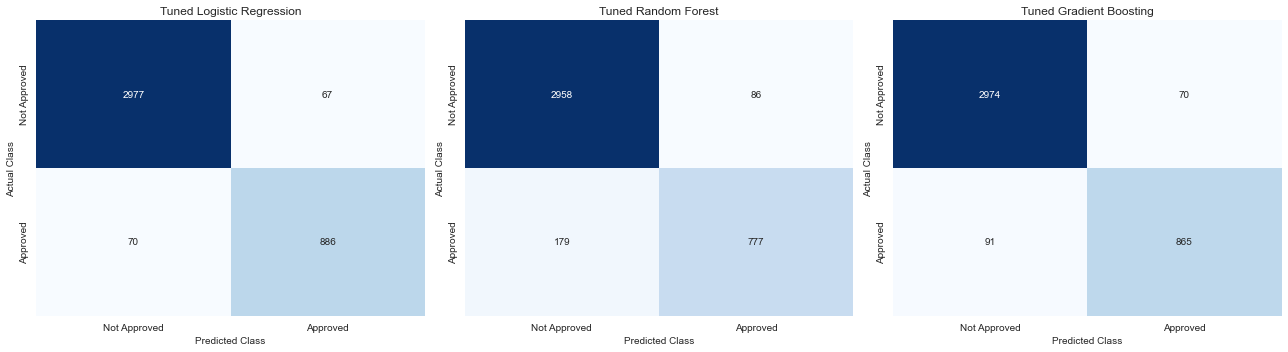

In [94]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

confusion_matrices = [
    (cm_logistic, "Tuned Logistic Regression"),
    (cm_rf, "Tuned Random Forest"),
    (cm_gb, "Tuned Gradient Boosting")
]

for ax, (cm, title) in zip(axes, confusion_matrices):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )
    
    ax.set_title(title)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")
    ax.set_xticklabels(["Not Approved", "Approved"])
    ax.set_yticklabels(["Not Approved", "Approved"])

plt.tight_layout()
plt.show()

### ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve is used to compare the classification performance of the tuned models across different probability thresholds.

The curve plots the true positive rate against the false positive rate. The Area Under the Curve (ROC-AUC) summarizes the model's ability to distinguish between approved and non-approved loan applications.

A higher ROC-AUC indicates stronger discrimination between the two classes. The ROC curves are compared alongside the confusion matrices and business-cost results to provide a more complete evaluation of model performance.

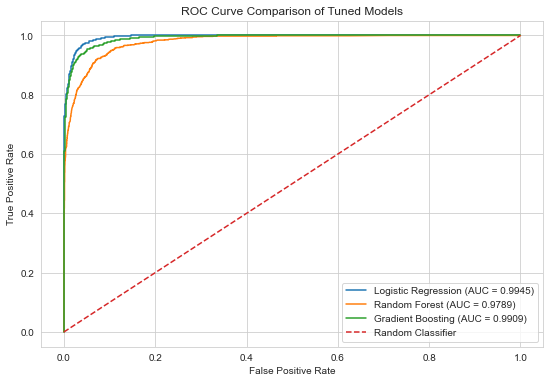

In [95]:
from sklearn.metrics import roc_curve

# Get predicted probabilities
y_proba_logistic = logistic_grid.best_estimator_.predict_proba(X_test)[:, 1]
y_proba_rf = rf_grid.best_estimator_.predict_proba(X_test)[:, 1]
y_proba_gb = gb_grid.best_estimator_.predict_proba(X_test)[:, 1]

# Calculate ROC curves
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_proba_logistic)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)

# Plot ROC curves
plt.figure(figsize=(9, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_logistic):.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.4f})"
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, y_proba_gb):.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Tuned Models")
plt.legend()
plt.grid(True)
plt.show()

### ROC Curve Interpretation

The ROC curves show strong discrimination for all three tuned models, with each curve remaining well above the random-classifier reference line.

Tuned Logistic Regression achieved a test ROC-AUC of 0.9945, while Tuned Gradient Boosting achieved 0.9909 and Tuned Random Forest achieved 0.9789.

These results indicate that all three tuned models can effectively distinguish between approved and non-approved loan applications. ROC-AUC is considered together with recall, confusion-matrix results, and business cost because strong discrimination alone does not capture the financial consequences of classification errors.

### Business Impact of Classification Errors

The financial impact of model errors is evaluated using the business costs provided by FinTech Innovations.

A false negative has an estimated opportunity cost of $8,000 because a potentially creditworthy applicant is not approved. A false positive has an estimated loss of $50,000 because an approved loan may subsequently default.

The total estimated business cost is therefore calculated as:

**Total Business Cost = (False Negatives × $8,000) + (False Positives × $50,000)**

This analysis helps connect statistical model performance to the financial consequences of loan approval decisions.

In [96]:
business_impact_results = pd.DataFrame({
    "Model": [
        "Tuned Logistic Regression",
        "Tuned Random Forest",
        "Tuned Gradient Boosting"
    ],
    "False Negatives": [
        70,
        179,
        91
    ],
    "False Positives": [
        67,
        86,
        70
    ],
    "False Negative Cost": [
        70 * 8000,
        179 * 8000,
        91 * 8000
    ],
    "False Positive Cost": [
        67 * 50000,
        86 * 50000,
        70 * 50000
    ],
    "Total Business Cost": [
        3910000,
        5732000,
        4228000
    ]
})

business_impact_results

,Model,False Negatives,False Positives,False Negative Cost,False Positive Cost,Total Business Cost
0,Tuned Logistic Regression,70,67,560000,3350000,3910000
1,Tuned Random Forest,179,86,1432000,4300000,5732000
2,Tuned Gradient Boosting,91,70,728000,3500000,4228000


### Feature Importance and Model Interpretation

Understanding which features contribute most strongly to model predictions is important for loan decision-making, transparency, and regulatory considerations.

Because Logistic Regression provides interpretable coefficients, its coefficients are examined to identify the features with the strongest influence on the model's predictions.

The preprocessing pipeline creates additional encoded features for categorical variables. Therefore, the feature names are retrieved from the fitted ColumnTransformer before interpreting the model coefficients.

The magnitude of a coefficient indicates the strength of its contribution, while its sign indicates the direction of the relationship with the predicted approval class.

In [98]:
# Get the fitted Logistic Regression pipeline
fitted_logistic = logistic_grid.best_estimator_

# Get the fitted preprocessor
fitted_preprocessor = fitted_logistic.named_steps["preprocessor"]

# Get the fitted Logistic Regression model
fitted_model = fitted_logistic.named_steps["model"]

# Get feature names from each preprocessing section

# 1. Numerical features
numeric_feature_names = [
    f"numeric__{feature}"
    for feature in numeric_features
    if feature != "AnnualIncome"
]

# 2. Annual income
annual_income_feature_names = [
    "annual_income__AnnualIncome"
]

# 3. Ordinal feature
ordinal_feature_names = [
    "ordinal__EducationLevel"
]

# 4. One-hot encoded categorical features
categorical_encoder = (
    fitted_preprocessor
    .named_transformers_["categorical"]
    .named_steps["encoder"]
)

categorical_feature_names = [
    f"categorical__{feature}"
    for feature in categorical_encoder.get_feature_names_out(
        categorical_features_for_pipeline
    )
]

# Combine all feature names in ColumnTransformer order
feature_names = (
    numeric_feature_names
    + annual_income_feature_names
    + ordinal_feature_names
    + categorical_feature_names
)

# Get Logistic Regression coefficients
logistic_coefficients = fitted_model.coef_[0]

# Check that the number of names matches the number of coefficients
print("Number of feature names:", len(feature_names))
print("Number of coefficients:", len(logistic_coefficients))

Number of feature names: 46
Number of coefficients: 46


In [99]:
# Create a DataFrame containing each feature and its Logistic Regression coefficient
logistic_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logistic_coefficients,
    "Absolute Coefficient": np.abs(logistic_coefficients)
})

# Sort the features by the absolute value of their coefficients.
# This puts the features with the strongest influence at the top,
# regardless of whether their coefficient is positive or negative.
logistic_feature_importance = (
    logistic_feature_importance
    .sort_values("Absolute Coefficient", ascending=False)
    .reset_index(drop=True)
)

# Display the 15 features with the largest absolute coefficients
logistic_feature_importance.head(15)

,Feature,Coefficient,Absolute Coefficient
0,numeric__TotalDebtToIncomeRatio,-10.669471,10.669471
1,numeric__InterestRate,-5.975949,5.975949
2,numeric__MonthlyIncome,5.151702,5.151702
3,categorical__BankruptcyHistory_Yes,-3.712025,3.712025
4,categorical__BankruptcyHistory_No,3.663858,3.663858
5,numeric__NetWorth,3.181156,3.181156
6,numeric__LoanAmount,-2.459981,2.459981
7,categorical__EmploymentStatus_Unemployed,-2.444623,2.444623
8,numeric__CreditScore,-2.373743,2.373743
9,numeric__LengthOfCreditHistory,1.919962,1.919962


### Feature Importance Visualization

The 15 features with the largest absolute Logistic Regression coefficients are visualized to make the model's most influential predictors easier to identify.

Positive coefficients indicate an association with the predicted approval class, while negative coefficients indicate an association with the non-approval class, holding the other features in the model constant.

This visualization supports model interpretability and helps identify financial and applicant characteristics that are most strongly associated with the model's loan approval predictions.

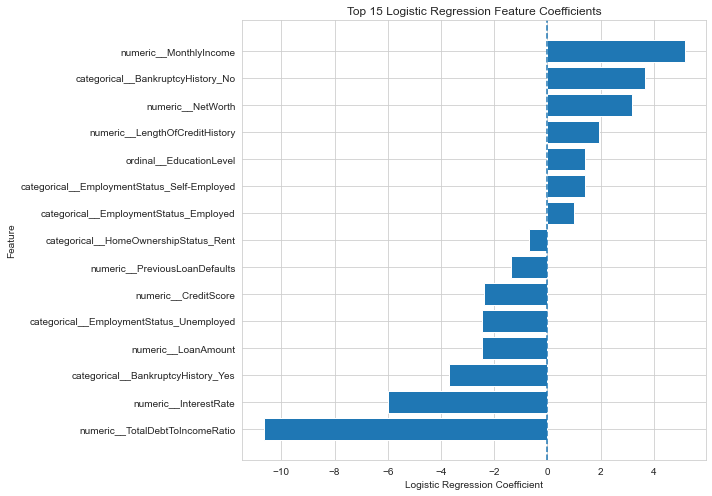

In [100]:
# Select the 15 features with the largest absolute coefficients
top_features = logistic_feature_importance.head(15).copy()

# Sort the features so the strongest effects appear at the top of the chart
top_features = top_features.sort_values("Coefficient")

# Create the feature-importance plot
plt.figure(figsize=(10, 7))

# Plot the signed coefficients so we can see both direction and magnitude
plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

# Add a vertical reference line at zero
plt.axvline(0, linestyle="--")

# Add chart labels and title
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Logistic Regression Feature Coefficients")

# Adjust spacing so feature names are visible
plt.tight_layout()

# Display the chart
plt.show()

### Business Interpretation of Important Features

The feature-importance analysis highlights several financial and credit-related variables that have strong associations with the Logistic Regression model's predictions.

TotalDebtToIncomeRatio has the largest absolute coefficient and a negative association with the predicted approval class. This indicates that higher debt relative to income is strongly associated with lower predicted approval probability in the model.

InterestRate also has a strong negative coefficient, while MonthlyIncome has a positive coefficient. Bankruptcy history is another important predictor, with the `Yes` category having a negative coefficient relative to the corresponding reference category.

NetWorth has a positive coefficient, while LoanAmount and CreditScore have negative coefficients in the fitted model.

These relationships should be interpreted as model associations rather than causal effects. The findings can help FinTech Innovations identify variables that deserve attention during risk assessment, but they should not be used as the sole basis for automated lending decisions without further validation, fairness assessment, and regulatory review.

### Performance Across Applicant Segments

Model performance can vary across different applicant groups. Evaluating approval rates and model predictions across categorical segments helps identify whether the model behaves differently for different groups.

Employment Status and Education Level are examined because they are categorical applicant characteristics included in the dataset and showed differences in historical approval rates during exploratory analysis.

This analysis is descriptive and is intended to identify potential performance differences that should be investigated further. Differences between groups do not by themselves establish that the model is biased or unfair.

In [101]:
# Create a copy of the test set for segment analysis
segment_analysis = X_test.copy()

# Add the actual target values
segment_analysis["ActualLoanApproved"] = y_test.values

# Add predictions from the tuned Logistic Regression model
segment_analysis["PredictedLoanApproved"] = y_pred_logistic_tuned

# Add prediction probabilities
segment_analysis["ApprovalProbability"] = y_proba_logistic

# Calculate actual and predicted approval rates by Employment Status
employment_segment_results = (
    segment_analysis
    .groupby("EmploymentStatus")
    .agg(
        Applications=("ActualLoanApproved", "count"),
        ActualApprovalRate=("ActualLoanApproved", "mean"),
        PredictedApprovalRate=("PredictedLoanApproved", "mean")
    )
    .reset_index()
)

employment_segment_results

,EmploymentStatus,Applications,ActualApprovalRate,PredictedApprovalRate
0,Employed,3402,0.242210,0.240447
1,Self-Employed,311,0.263666,0.286174
2,Unemployed,287,0.174216,0.160279


### Education Level Segment Analysis

Education Level is evaluated as a second applicant segment to determine whether the model's predicted approval rates are broadly consistent with the observed approval rates across education groups.

As with Employment Status, differences between actual and predicted approval rates are descriptive and do not by themselves establish model bias. Smaller groups should also be interpreted cautiously because their estimates are based on fewer observations.

In [102]:
# Calculate actual and predicted approval rates by Education Level
education_segment_results = (
    segment_analysis
    .groupby("EducationLevel", dropna=False)
    .agg(
        Applications=("ActualLoanApproved", "count"),
        ActualApprovalRate=("ActualLoanApproved", "mean"),
        PredictedApprovalRate=("PredictedLoanApproved", "mean")
    )
    .reset_index()
)

# Display the segment-level results
education_segment_results

,EducationLevel,Applications,ActualApprovalRate,PredictedApprovalRate
0,Associate,782,0.207161,0.204604
1,Bachelor,1163,0.279450,0.278590
2,Doctorate,156,0.442308,0.448718
3,High School,1086,0.152855,0.147330
4,Master,620,0.377419,0.375806
5,NaN,193,0.000000,0.031088


### Segment Approval Rate Visualization

The actual and predicted approval rates are visualized across Employment Status and Education Level segments.

Comparing the two rates provides a simple way to identify groups where model predictions differ from the observed outcomes. These differences are interpreted descriptively and should be investigated further rather than being treated as evidence of bias on their own.

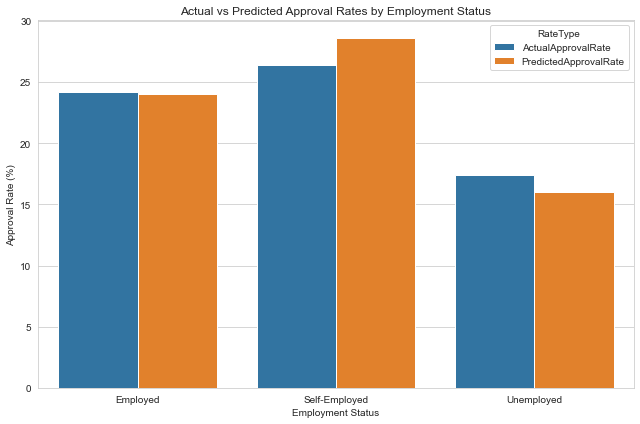

In [103]:
# Create a copy of the employment segment results for plotting
employment_plot = employment_segment_results.copy()

# Reshape the data so actual and predicted rates can be plotted together
employment_plot = employment_plot.melt(
    id_vars="EmploymentStatus",
    value_vars=[
        "ActualApprovalRate",
        "PredictedApprovalRate"
    ],
    var_name="RateType",
    value_name="ApprovalRate"
)

# Convert rates to percentages for easier interpretation
employment_plot["ApprovalRate"] = employment_plot["ApprovalRate"] * 100

# Create the grouped bar chart
plt.figure(figsize=(9, 6))

sns.barplot(
    data=employment_plot,
    x="EmploymentStatus",
    y="ApprovalRate",
    hue="RateType"
)

# Add labels and title
plt.xlabel("Employment Status")
plt.ylabel("Approval Rate (%)")
plt.title("Actual vs Predicted Approval Rates by Employment Status")

# Display the chart
plt.tight_layout()
plt.show()

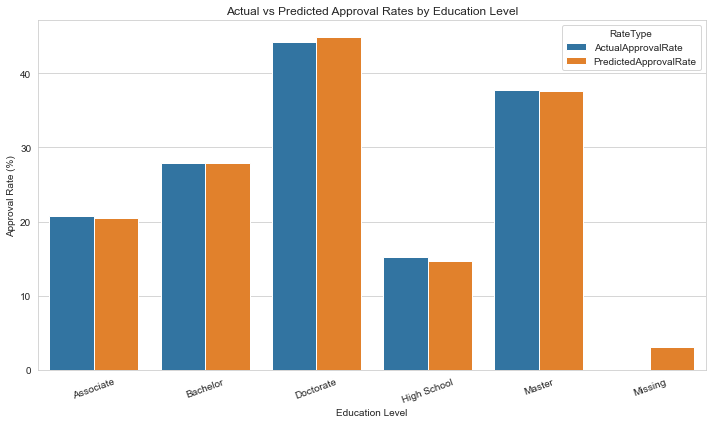

In [104]:
# Create a copy of the education segment results for plotting
education_plot = education_segment_results.copy()

# Replace missing education values with a readable label
education_plot["EducationLevel"] = (
    education_plot["EducationLevel"]
    .fillna("Missing")
)

# Reshape the data so actual and predicted rates can be plotted together
education_plot = education_plot.melt(
    id_vars="EducationLevel",
    value_vars=[
        "ActualApprovalRate",
        "PredictedApprovalRate"
    ],
    var_name="RateType",
    value_name="ApprovalRate"
)

# Convert rates to percentages for easier interpretation
education_plot["ApprovalRate"] = education_plot["ApprovalRate"] * 100

# Create the grouped bar chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=education_plot,
    x="EducationLevel",
    y="ApprovalRate",
    hue="RateType"
)

# Add labels and title
plt.xlabel("Education Level")
plt.ylabel("Approval Rate (%)")
plt.title("Actual vs Predicted Approval Rates by Education Level")

# Rotate labels slightly for readability
plt.xticks(rotation=20)

# Adjust spacing
plt.tight_layout()

# Display the chart
plt.show()

### Bias, Fairness, and Model Limitations

The segment analysis provides an initial check of how model predictions compare with observed approval rates across Employment Status and Education Level groups. The results show some differences between actual and predicted approval rates, although the differences alone do not establish that the model is biased or unfair.

Several limitations should be considered:

1. **Historical data:** The model learns patterns from previous loan decisions. If historical decisions contained systematic biases, those patterns could potentially be reflected in the model.

2. **Class imbalance:** Only 23.9% of applications belong to the approved class, compared with 76.1% in the non-approved class. Accuracy should therefore not be used as the only performance measure.

3. **Missing values:** Education Level and other variables contain missing observations. Although the preprocessing pipeline imputes missing values, the missingness itself may contain information that is not fully captured by simple imputation.

4. **Feature relationships:** Several numerical features are strongly correlated with one another. For example, Age and Experience, and TotalAssets and NetWorth, showed high correlations during exploratory analysis. This may affect coefficient interpretation in the Logistic Regression model.

5. **Model associations are not causal:** Feature coefficients indicate associations used by the model for prediction. They should not be interpreted as evidence that changing a feature will directly cause a change in loan approval.

6. **Limited fairness analysis:** The current segment analysis examines approval-rate differences but does not provide a complete fairness assessment. Additional metrics such as false-positive and false-negative rates across groups would be required for a more comprehensive fairness evaluation.

7. **Operational and regulatory review:** Before deployment, the model should be subjected to additional validation, monitoring, explainability checks, and appropriate regulatory and compliance review.

### Segment-Level Error Rate Analysis

Approval-rate comparisons alone do not provide a complete assessment of model behavior across applicant groups. Therefore, false-positive and false-negative rates are also examined by Employment Status.

The false-positive rate measures the proportion of applicants in a group who belong to the non-approved class but are predicted as approved. The false-negative rate measures the proportion of applicants in a group who belong to the approved class but are predicted as non-approved.

Comparing these rates across groups provides additional information about whether different groups experience different types of classification errors. These comparisons are descriptive and should be followed by more comprehensive fairness testing before deployment.

In [105]:
# Create a copy of the test data for segment-level error analysis
error_analysis = X_test.copy()

# Add the actual loan approval outcome
error_analysis["Actual"] = y_test.values

# Add the tuned Logistic Regression predictions
error_analysis["Predicted"] = y_pred_logistic_tuned

# Create indicators for false positives and false negatives
error_analysis["FalsePositive"] = (
    (error_analysis["Actual"] == 0) &
    (error_analysis["Predicted"] == 1)
).astype(int)

error_analysis["FalseNegative"] = (
    (error_analysis["Actual"] == 1) &
    (error_analysis["Predicted"] == 0)
).astype(int)

# Calculate the number of actual non-approved and approved applications
# within each employment group
employment_error_rates = (
    error_analysis
    .groupby("EmploymentStatus")
    .apply(
        lambda group: pd.Series({
            "Applications": len(group),
            "FalsePositiveRate": (
                group["FalsePositive"].sum() /
                (group["Actual"] == 0).sum()
                if (group["Actual"] == 0).sum() > 0 else np.nan
            ),
            "FalseNegativeRate": (
                group["FalseNegative"].sum() /
                (group["Actual"] == 1).sum()
                if (group["Actual"] == 1).sum() > 0 else np.nan
            )
        })
    )
    .reset_index()
)

employment_error_rates

,EmploymentStatus,Applications,FalsePositiveRate,FalseNegativeRate
0,Employed,3402.0,0.020559,0.071602
1,Self-Employed,311.0,0.043668,0.036585
2,Unemployed,287.0,0.016878,0.160000


### Final Model Performance Summary

The final tuned models are compared using test-set performance and estimated business cost. This summary combines conventional classification metrics with the financial consequences of classification errors.

The comparison is used to support the final business discussion. Model selection should consider predictive performance, error patterns, business cost, interpretability, and operational requirements rather than relying on a single metric.

In [106]:
# Create a final summary table for the tuned models
final_model_summary = tuned_test_results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "ROC-AUC",
        "False Negatives",
        "False Positives",
        "Business Cost"
    ]
].copy()

# Display the final model comparison
final_model_summary

,Model,Accuracy,Precision,Recall,ROC-AUC,False Negatives,False Positives,Business Cost
0,Tuned Logistic Regression,0.96575,0.929696,0.926778,0.994543,70,67,3910000
1,Tuned Random Forest,0.93375,0.900348,0.812762,0.978919,179,86,5732000
2,Tuned Gradient Boosting,0.95975,0.925134,0.904812,0.990895,91,70,4228000


### Final Model Business Cost Comparison

Estimated business cost is compared across the tuned models to highlight the financial consequences of their classification errors.

The business cost combines the opportunity cost of false negatives and the financial loss associated with false positives. This provides a direct connection between model performance and the financial objective of the lending business.

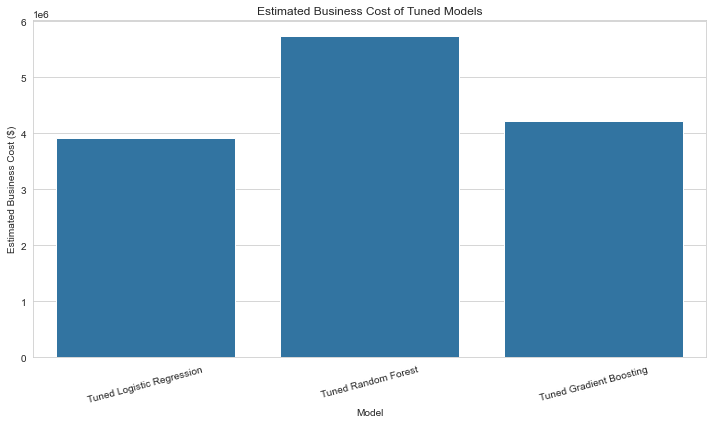

In [107]:
# Create a copy of the final model results for visualization
business_cost_plot = final_model_summary.copy()

# Create the business cost bar chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=business_cost_plot,
    x="Model",
    y="Business Cost"
)

# Add chart labels and title
plt.xlabel("Model")
plt.ylabel("Estimated Business Cost ($)")
plt.title("Estimated Business Cost of Tuned Models")

# Rotate model names for readability
plt.xticks(rotation=15)

# Adjust spacing
plt.tight_layout()

# Display the chart
plt.show()

### Final Evaluation Interpretation

The final test-set evaluation shows that all three tuned models provide strong classification performance, but their error patterns and estimated business costs differ.

Tuned Logistic Regression achieved an accuracy of 96.58%, precision of 92.97%, recall of 92.68%, and ROC-AUC of 99.45%. It produced 70 false negatives and 67 false positives, resulting in an estimated business cost of $3.91 million.

Tuned Gradient Boosting achieved an accuracy of 95.98%, precision of 92.51%, recall of 90.48%, and ROC-AUC of 99.09%. It produced 91 false negatives and 70 false positives, resulting in an estimated business cost of $4.228 million.

Tuned Random Forest achieved an accuracy of 93.38%, precision of 90.03%, recall of 81.28%, and ROC-AUC of 97.89%. It produced 179 false negatives and 86 false positives, resulting in an estimated business cost of $5.732 million.

Considering both predictive performance and the asymmetric financial consequences of classification errors, the tuned Logistic Regression configuration provides the strongest overall alignment with the stated business objectives among the evaluated tuned models. Its relatively low number of false negatives and false positives also results in the lowest estimated business cost in the final test-set comparison.

This conclusion is based on the available test-set results and should be validated through additional monitoring, fairness testing, and prospective evaluation before production deployment.

### Potential Improvements

Future iterations of the project could improve the analysis and model by:

- Testing additional classification algorithms and ensemble methods.
- Exploring more advanced feature engineering based on financial ratios and applicant payment behavior.
- Performing more comprehensive fairness analysis using group-specific error rates and other appropriate fairness metrics.
- Evaluating alternative classification thresholds based on different business risk scenarios.
- Comparing different missing-value treatment strategies.
- Investigating whether highly correlated predictors can be reduced or combined.
- Conducting prospective validation on new loan applications before full deployment.
- Monitoring model drift and changes in the underlying applicant population over time.

### Executive Summary

FinTech Innovations aims to improve its manual loan approval process by using historical application data to support more consistent and efficient lending decisions. A classification approach was selected because the target variable, `LoanApproved`, represents a binary loan approval outcome.

The dataset contained 20,000 loan applications and 35 variables representing applicant characteristics, financial information, credit history, and loan details. Exploratory analysis identified numerical, categorical, and ordinal features, class imbalance in the target variable, missing values, outliers, and strong relationships among several numerical predictors.

A preprocessing pipeline was developed using `ColumnTransformer` and `Pipeline`. Numerical features were median-imputed and standardized, categorical features were imputed and one-hot encoded, the ordinal education variable was encoded according to its ordered levels, and annual income was cleaned from currency-formatted text before conversion to a numerical variable.

Five classification algorithms were evaluated: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, and K-Nearest Neighbors. The models were assessed using accuracy, precision, recall, ROC-AUC, and estimated business cost. Five-fold stratified cross-validation was then used to evaluate model stability, followed by GridSearchCV hyperparameter tuning for Logistic Regression, Random Forest, and Gradient Boosting.

The final test-set evaluation showed that the tuned Logistic Regression model achieved an accuracy of 96.58%, precision of 92.97%, recall of 92.68%, and ROC-AUC of 99.45%. It produced 70 false negatives and 67 false positives, resulting in an estimated business cost of $3.91 million. Tuned Gradient Boosting produced a business cost of $4.228 million, while Tuned Random Forest produced a business cost of $5.732 million.

The results indicate that the tuned Logistic Regression configuration provides a strong combination of predictive performance, business-cost performance, and interpretability for this analysis. However, the model should be treated as a decision-support system rather than an autonomous lending decision-maker until additional validation, fairness assessment, regulatory review, and prospective testing have been completed.

### Conclusion

The analysis demonstrates how machine learning can be incorporated into the loan approval process to support data-driven decision-making.

The modeling results show that strong predictive performance can be achieved while explicitly considering the financial consequences of classification errors. The use of business cost was particularly important because a false positive was associated with a substantially larger estimated financial loss than a false negative.

The final evaluation also demonstrated the importance of evaluating models beyond accuracy. ROC-AUC, precision, recall, confusion matrices, business cost, segment-level performance, and model interpretability provided complementary perspectives on model quality.

The tuned Logistic Regression model provided the strongest combination of these considerations in the evaluated test set. Its relatively high recall helps identify approved applications, while its relatively low number of false positives limits the estimated cost associated with approving loans that may default. Its coefficients also provide a comparatively interpretable way to understand the variables contributing to predictions.

However, the model should not be considered production-ready based solely on this analysis. Further work is required to validate the model on new data, monitor performance over time, investigate fairness across relevant applicant groups, assess alternative classification thresholds, and ensure compliance with applicable lending and data-protection requirements.

Overall, the project provides FinTech Innovations with a structured machine-learning approach for improving loan approval decision support while recognizing the financial, operational, and fairness considerations involved in deploying predictive models in lending.